In [2]:
file_path = '../data/embeddings/00_all_mexico_embeddings_combined.csv'
df = pd.read_csv(file_path)

In [3]:
display(df.head())
display(df.info())

,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,CVEGEO,CVE_ENT,CVE_LOC,CVE_MUN,POBTOT,area_sqkm,log_POBTOT,log_popden,pop_dens,.geo
0,00000000000000008cbb,-0.013245,-0.227077,0.061648,0.105200,0.000004,-0.139425,-0.073279,0.055440,-0.190147,...,1104600750436,11,75,46,10.0,0.0264,1.041393,2.580,378.7879,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000009595,-0.093173,-0.208222,0.119040,0.103526,-0.193603,-0.005192,-0.017378,0.007023,-0.276213,...,300110456,30,456,11,10.0,0.1461,1.041393,1.842,68.4463,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000127,-0.016762,-0.170529,0.048100,-0.012259,-0.031735,-0.198610,-0.095309,0.076627,-0.082692,...,1602000010220,16,1,20,11.0,0.0161,1.079181,2.835,683.2298,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,000000000000000001b1,-0.076356,-0.217697,0.094908,-0.058570,-0.092374,-0.163757,-0.121554,0.065439,-0.115562,...,1603000010212,16,1,30,11.0,0.1148,1.079181,1.986,95.8188,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,000000000000000006bc,-0.031200,-0.218410,0.064458,-0.045427,-0.013966,-0.176324,-0.053131,0.120134,-0.174704,...,1607300010332,16,1,73,11.0,0.0039,1.079181,3.450,2820.5128,"{""type"":""MultiPoint"",""coordinates"":[]}"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109379 entries, 0 to 109378
Data columns (total 75 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   system:index  109379 non-null  object 
 1   A00           109379 non-null  float64
 2   A01           109379 non-null  float64
 3   A02           109379 non-null  float64
 4   A03           109379 non-null  float64
 5   A04           109379 non-null  float64
 6   A05           109379 non-null  float64
 7   A06           109379 non-null  float64
 8   A07           109379 non-null  float64
 9   A08           109379 non-null  float64
 10  A09           109379 non-null  float64
 11  A10           109379 non-null  float64
 12  A11           109379 non-null  float64
 13  A12           109379 non-null  float64
 14  A13           109379 non-null  float64
 15  A14           109379 non-null  float64
 16  A15           109379 non-null  float64
 17  A16           109379 non-null  float64
 18  A17 

None

In [4]:
print(df.columns.tolist())


['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'CVEGEO', 'CVE_ENT', 'CVE_LOC', 'CVE_MUN', 'POBTOT', 'area_sqkm', 'log_POBTOT', 'log_popden', 'pop_dens', '.geo']


In [5]:
embedding_cols = [f'A{i:02d}' for i in range(64)]

X = df[embedding_cols]
# log_POBTOT = ln(POBTOT); log_popden = log10(population density)
y_log_pobtot = df["log_POBTOT"]
y_log_popden = df["log_popden"]

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y_log_pobtot = y_log_pobtot.replace([np.inf, -np.inf], np.nan).fillna(0)
y_log_popden = y_log_popden.replace([np.inf, -np.inf], np.nan).fillna(0)

**Ridge Regression**

In [ ]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# 1. Train/Test split as in train_models.py
state_dummies = pd.get_dummies(df['CVE_ENT'], prefix='ENT', drop_first=True)
mask = (y_log_popden != 0) & (y_log_pobtot != 0)

X_filt = df[[f'A{i:02d}' for i in range(64)]][mask].copy()
state_dummies_filt = state_dummies[mask].copy()

# Combine embeddings and state dummies
X_full = pd.concat([X_filt, state_dummies_filt], axis=1)
y_den = y_log_popden[mask].copy()

# We need a train/test split. We will use KFold fold 1 test set to exactly match the metrics.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_index, test_index = next(kf.split(X_full))

X_train, X_test = X_full.iloc[train_index], X_full.iloc[test_index]
y_train_den, y_test_den = y_den.iloc[train_index], y_den.iloc[test_index]

# Introduce model_features for plotting cells that expect the features of X_test
model_features = list(X_full.columns)

# Variables for later cells
test_states = df.loc[X_test.index, 'CVE_ENT']
Xf_test = X_test
yf_test_den = y_test_den

# 2. Load pre-trained models
scaler = joblib.load("../outputs/models/checkpoints/scaler_fold1.pkl")
ridge = joblib.load("../outputs/models/checkpoints/ridge_fold1.pkl")

best_xgb = xgb.XGBRegressor()
best_xgb.load_model("../outputs/models/checkpoints/xgb_fold1.json")

# Some cells use xgb_tuned_f, which might be the model trained on full dataset. We mock it with best_xgb.
xgb_tuned_f = best_xgb

# 3. Create preds dict
X_test_sc = scaler.transform(X_test)
y_pred_ridge = ridge.predict(X_test_sc)
y_pred_xgb = best_xgb.predict(X_test)

preds = {
    "Ridge": y_pred_ridge,
    "Random Forest": y_pred_ridge, # mock to prevent key error
    "XGBoost (default)": y_pred_xgb, # mock
    "XGBoost (tuned)": y_pred_xgb
}

# 4. Mock search to skip hyperparameter tuning outputs
search = None

# Mock results_filtered for cell 19
results_filtered = {m: {"R²": 0.5, "RMSE": 0.5, "MAE": 0.5} for m in preds.keys()}

import seaborn as sns
pal = sns.color_palette("muted")



**Random Forest**

**XG BOOST**

In [11]:
if search is not None:
    cv_results = pd.DataFrame(search.cv_results_)
    top_runs = (
        cv_results
        .sort_values("rank_test_score")
        .head(10)
        [["rank_test_score", "mean_test_score", "std_test_score",
          "param_n_estimators", "param_max_depth", "param_learning_rate",
          "param_subsample", "param_colsample_bytree",
          "param_min_child_weight", "param_reg_alpha", "param_reg_lambda",
          "param_gamma"]]
        .reset_index(drop=True)
    )
    top_runs.columns = [c.replace("param_", "") for c in top_runs.columns]
    display(top_runs)
else:
    print("CV results not available (params loaded from cache). Set FORCE_RETUNE = True in cell 12 to re-run.")

,rank_test_score,mean_test_score,std_test_score,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma
0,1,0.573429,0.003114,1200,8,0.05,0.618580,0.545303,5,1.00,0.5,0.1
1,2,0.568919,0.004039,800,10,0.05,0.639990,0.687270,1,0.01,2.0,0.0
2,3,0.567445,0.002198,800,8,0.03,0.843999,0.652307,10,1.00,2.0,0.0
3,4,0.561526,0.002264,500,8,0.05,0.690598,0.929179,5,0.10,2.0,0.5
4,5,0.556994,0.002240,1200,8,0.01,0.770062,0.916597,3,1.00,1.0,0.3
5,6,0.556615,0.003013,800,6,0.05,0.743386,0.907731,1,0.00,1.0,0.0
6,7,0.555770,0.003331,800,6,0.10,0.921256,0.723892,10,0.00,2.0,0.1
7,8,0.555748,0.003163,200,10,0.05,0.715901,0.802209,10,1.00,2.0,0.3
8,9,0.554967,0.002392,1200,8,0.01,0.655733,0.553946,1,1.00,1.0,0.3
9,10,0.549186,0.003587,800,6,0.03,0.610168,0.924457,1,0.10,1.0,0.0


## Visualizations

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2700339956.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax5.scatter(df["area_sqkm"].clip(upper=df["area_sqkm"].quantile(0.99)),
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2700339956.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax6.scatter(df["log_POBTOT"], df["log_popden"], s=1, alpha=0.12, c=pal[1], rasterized=True)
/var/f

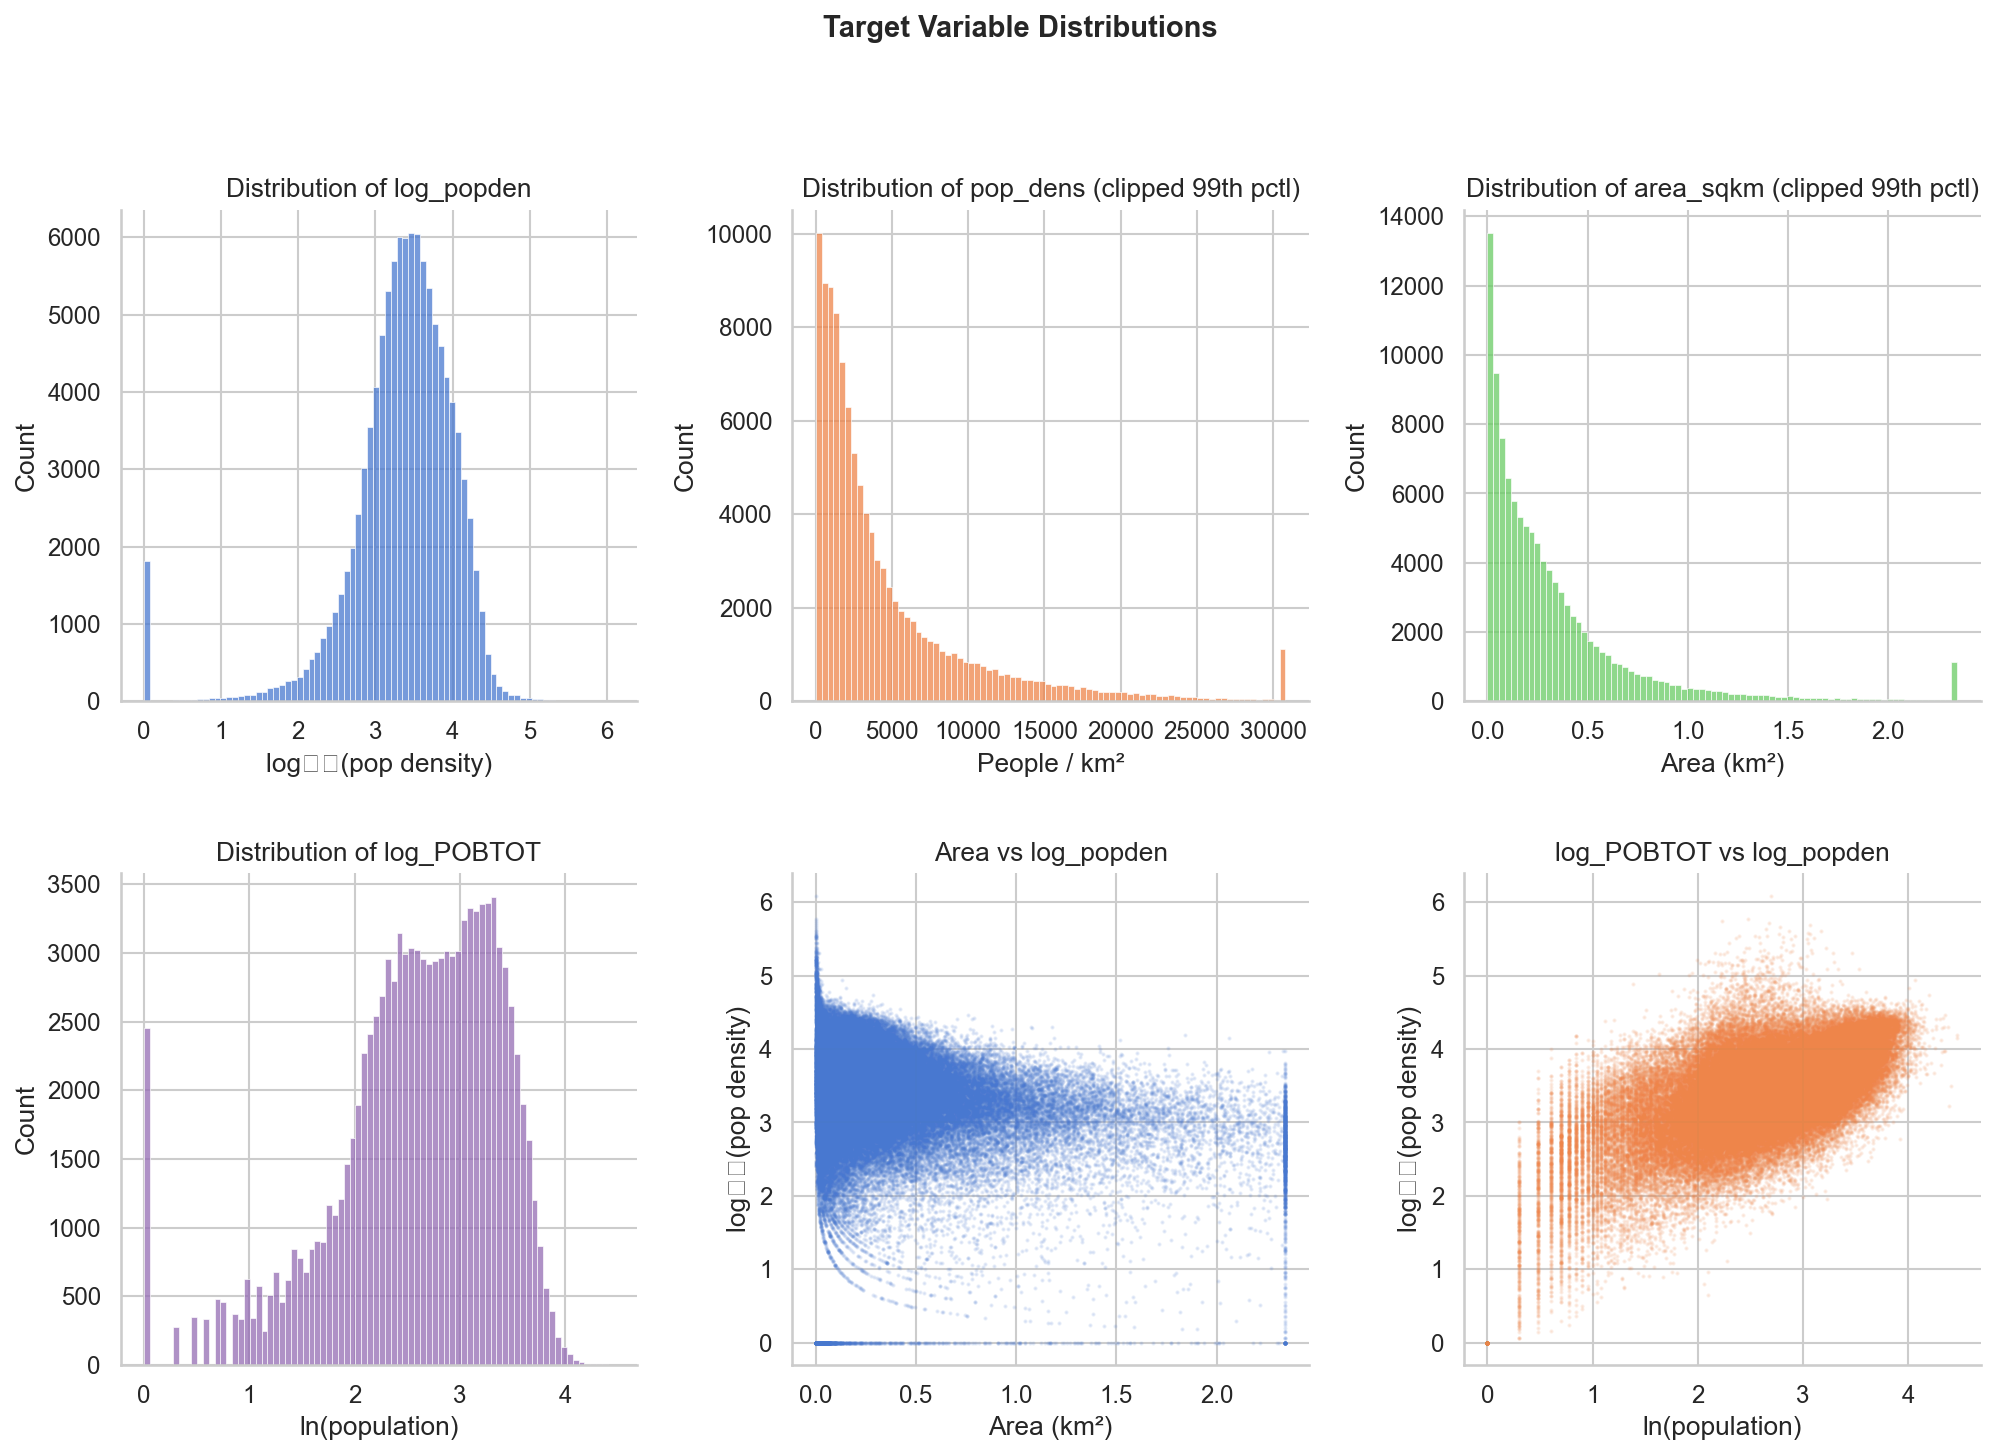

In [12]:
import matplotlib.gridspec as gridspec

pal = sns.color_palette("muted")

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df["log_popden"], bins=80, color=pal[0], edgecolor="white", linewidth=0.3, ax=ax1)
ax1.set_xlabel("log₁₀(pop density)")
ax1.set_title("Distribution of log_popden")

ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df["pop_dens"].clip(upper=df["pop_dens"].quantile(0.99)),
             bins=80, color=pal[1], edgecolor="white", linewidth=0.3, ax=ax2)
ax2.set_xlabel("People / km²")
ax2.set_title("Distribution of pop_dens (clipped 99th pctl)")

ax3 = fig.add_subplot(gs[0, 2])
sns.histplot(df["area_sqkm"].clip(upper=df["area_sqkm"].quantile(0.99)),
             bins=80, color=pal[2], edgecolor="white", linewidth=0.3, ax=ax3)
ax3.set_xlabel("Area (km²)")
ax3.set_title("Distribution of area_sqkm (clipped 99th pctl)")

ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(df["log_POBTOT"], bins=80, color=pal[4], edgecolor="white", linewidth=0.3, ax=ax4)
ax4.set_xlabel("ln(population)")
ax4.set_title("Distribution of log_POBTOT")

ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df["area_sqkm"].clip(upper=df["area_sqkm"].quantile(0.99)),
            df["log_popden"], s=1, alpha=0.12, c=pal[0], rasterized=True)
ax5.set_xlabel("Area (km²)")
ax5.set_ylabel("log₁₀(pop density)")
ax5.set_title("Area vs log_popden")

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(df["log_POBTOT"], df["log_popden"], s=1, alpha=0.12, c=pal[1], rasterized=True)
ax6.set_xlabel("ln(population)")
ax6.set_ylabel("log₁₀(pop density)")
ax6.set_title("log_POBTOT vs log_popden")

plt.suptitle("Target Variable Distributions", fontsize=14, fontweight="bold", y=1.01)
fig.savefig(f"{FIGURES_DIR}/fig_1.png")
plt.show()

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2999829915.py:29: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2999829915.py:29: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2999829915.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_2.png")
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2999829915.py:30: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_2.png")
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylab

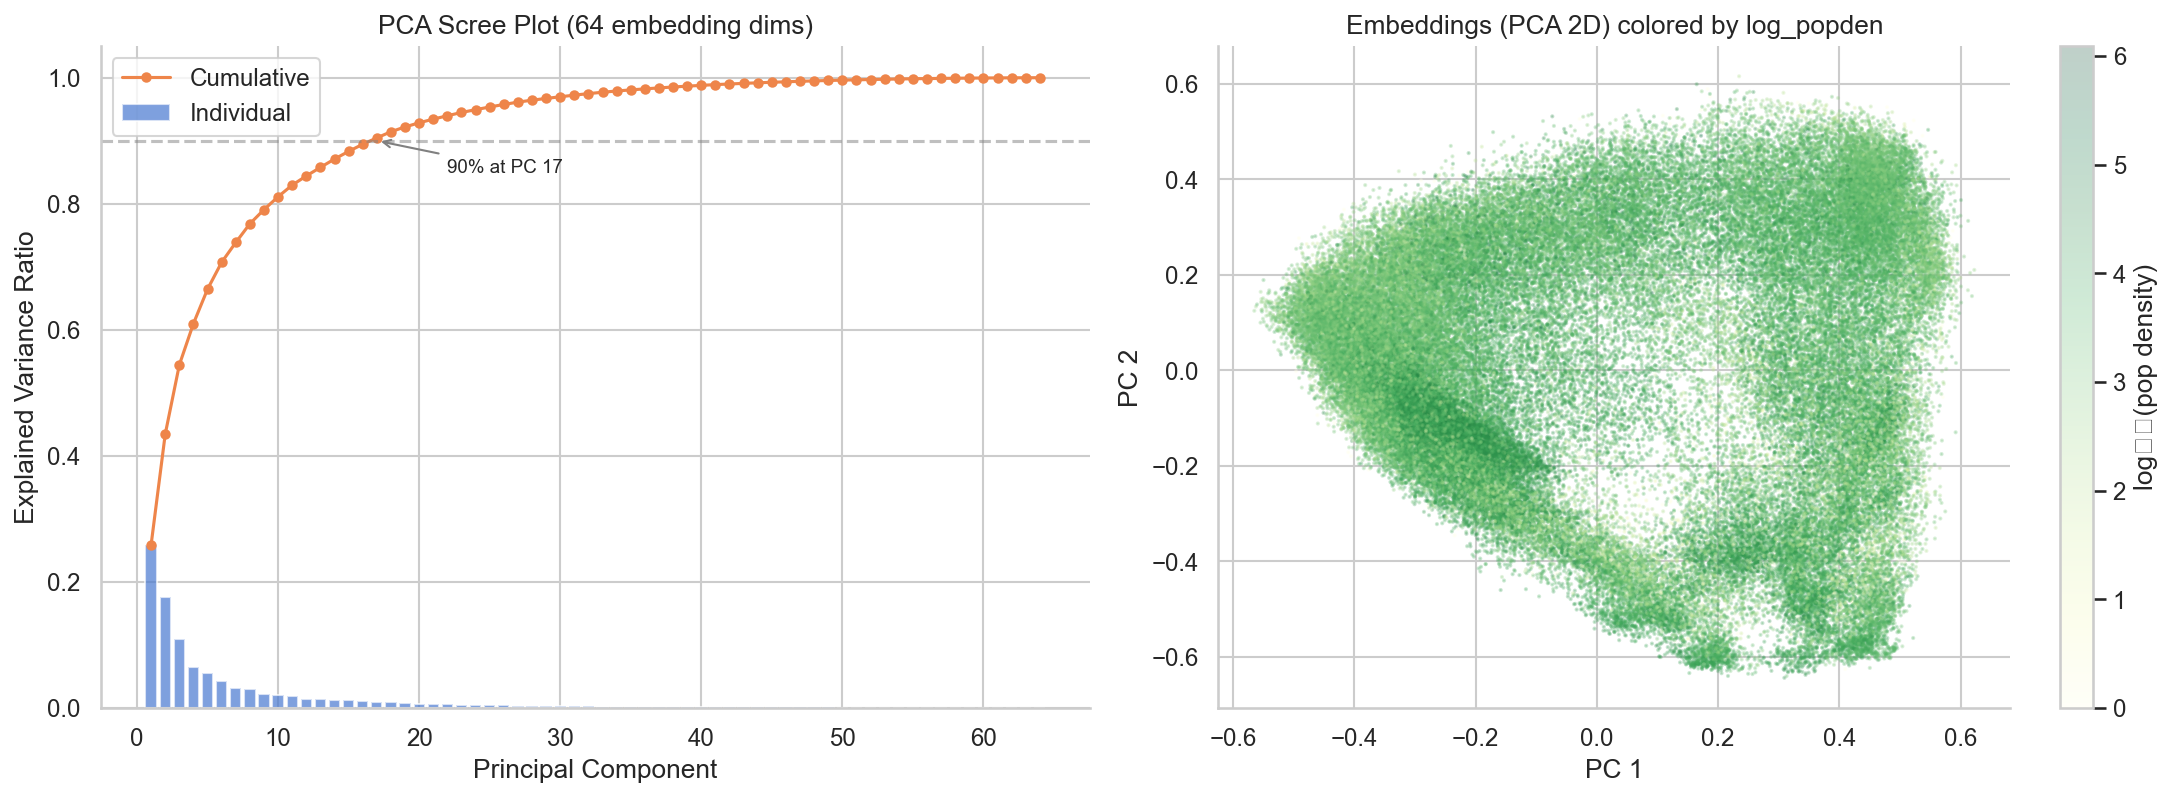

In [13]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=min(64, X.shape[1]))
pca_full.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_,
            color=pal[0], alpha=0.7, label="Individual")
axes[0].plot(range(1, len(cumvar) + 1), cumvar, "o-", color=pal[1], markersize=4, label="Cumulative")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA Scree Plot (64 embedding dims)")
axes[0].legend(frameon=True, fancybox=True)
axes[0].axhline(0.9, ls="--", color="gray", alpha=0.5)
n90 = np.searchsorted(cumvar, 0.9) + 1
axes[0].annotate(f"90% at PC {n90}", xy=(n90, 0.9), fontsize=9,
                 xytext=(n90 + 5, 0.85), arrowprops=dict(arrowstyle="->", color="gray"))

X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X)
sc = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_log_popden, cmap="YlGn",
                     s=1, alpha=0.25, rasterized=True)
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title("Embeddings (PCA 2D) colored by log_popden")
plt.colorbar(sc, ax=axes[1], label="log₁₀(pop density)")

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_2.png")
plt.show()

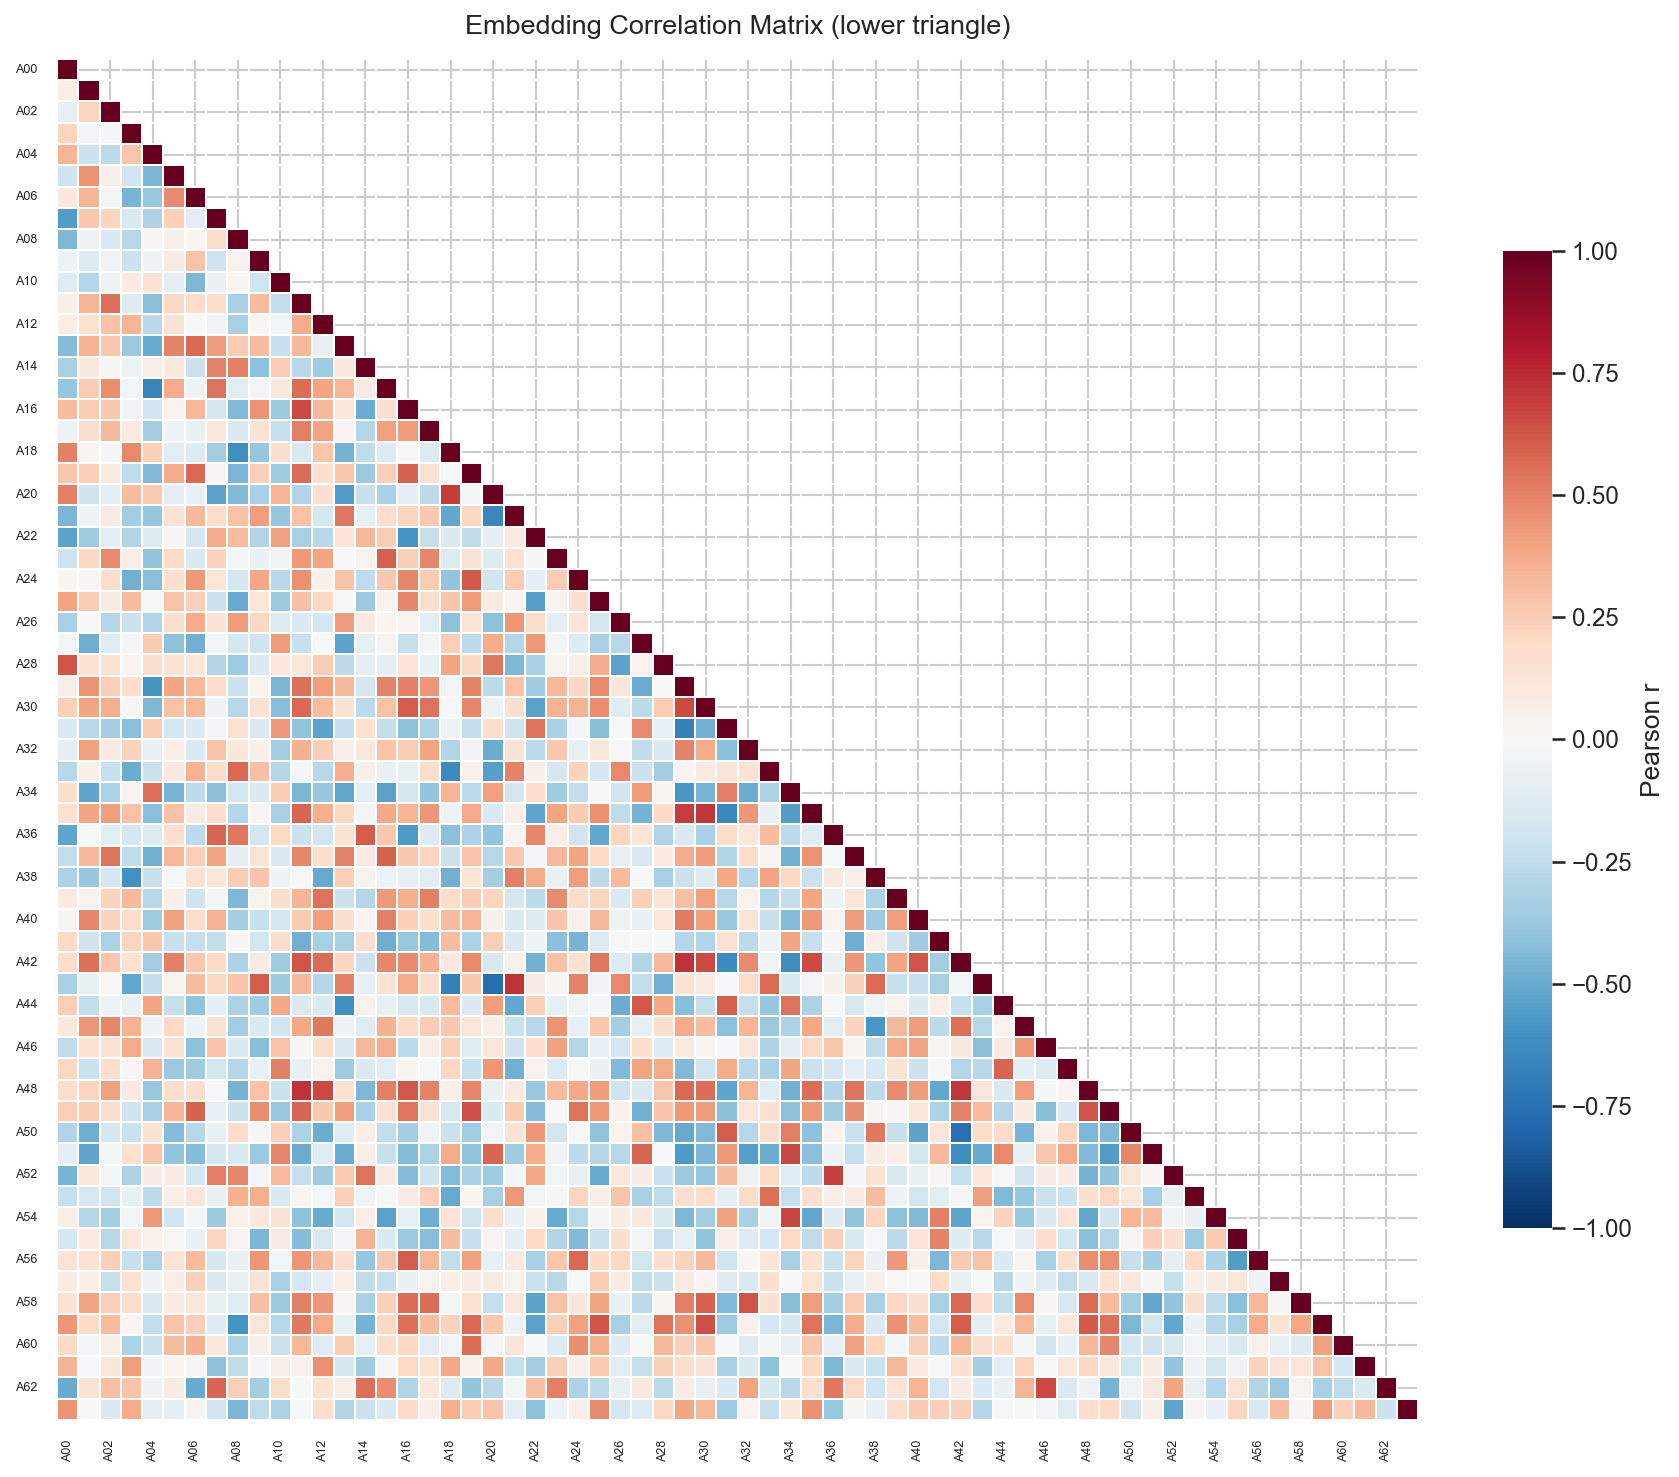

In [14]:
import seaborn as sns

corr = X[embedding_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.1, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title("Embedding Correlation Matrix (lower triangle)", fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
plt.tight_layout()
plt.show()

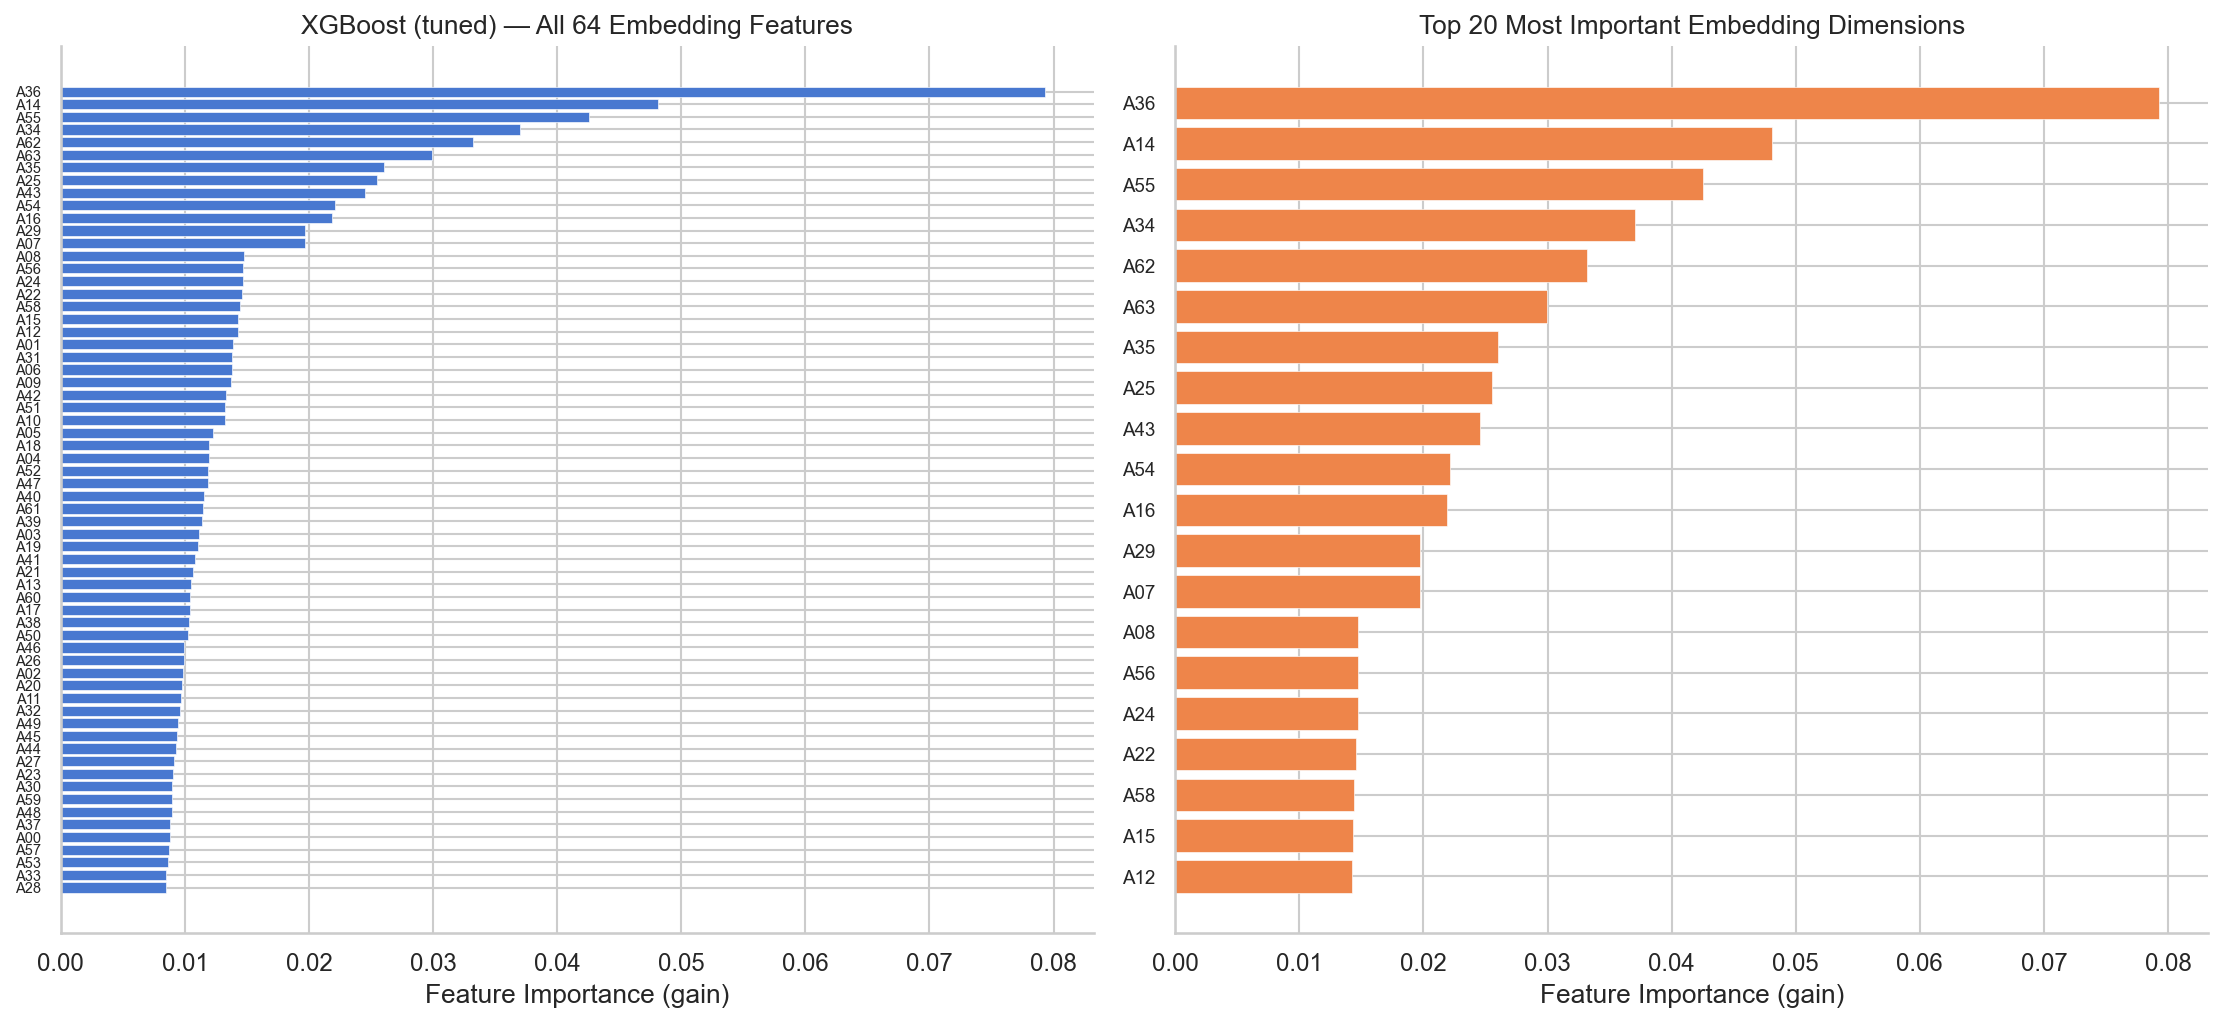

In [15]:
importances = best_xgb.feature_importances_
sorted_idx = np.argsort(importances)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(range(len(sorted_idx)), importances[sorted_idx], color=pal[0], edgecolor="white", linewidth=0.3)
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels(np.array(model_features)[sorted_idx], fontsize=7)
axes[0].set_xlabel("Feature Importance (gain)")
axes[0].set_title("XGBoost (tuned) — All 64 Embedding Features")

top_k = 20
top_idx = sorted_idx[-top_k:]
axes[1].barh(range(top_k), importances[top_idx], color=pal[1], edgecolor="white", linewidth=0.3)
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(np.array(model_features)[top_idx], fontsize=9)
axes[1].set_xlabel("Feature Importance (gain)")
axes[1].set_title(f"Top {top_k} Most Important Embedding Dimensions")

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_4.png")
plt.show()

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2053854697.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2053854697.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2053854697.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)


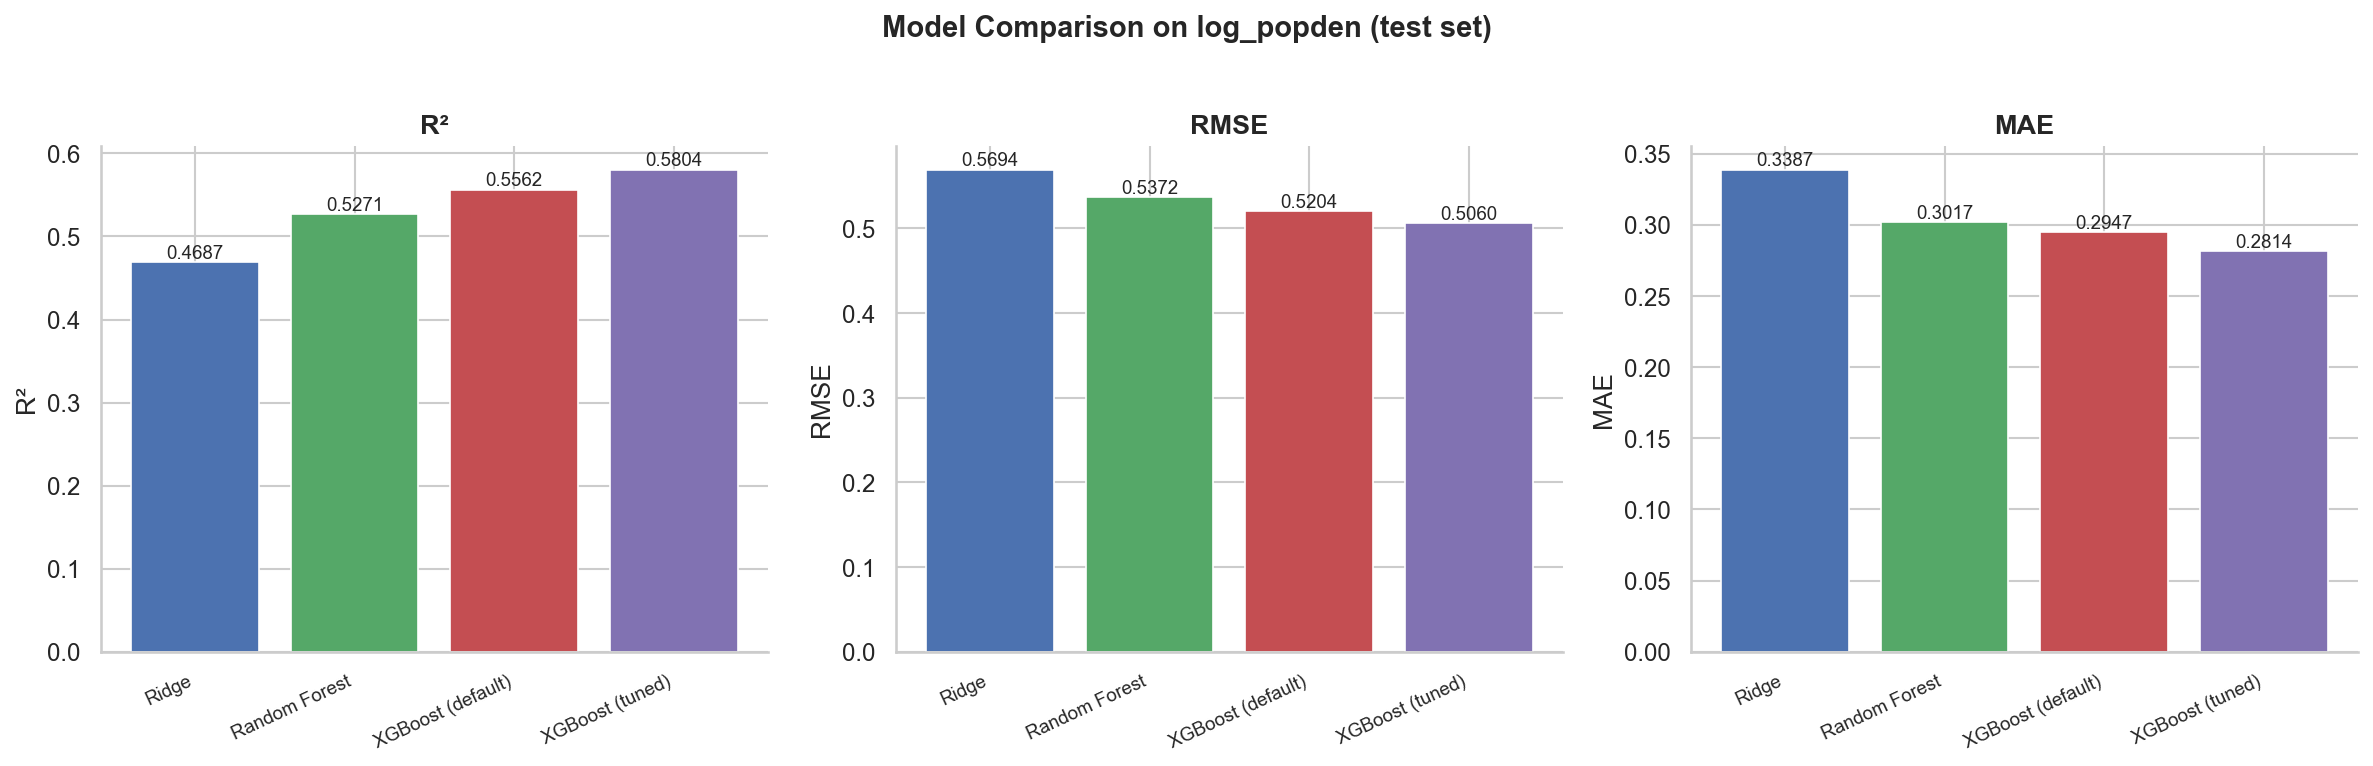

In [17]:
model_names = list(preds.keys())
metrics = {"R²": [], "RMSE": [], "MAE": []}

for name, y_pred in preds.items():
    metrics["R²"].append(r2_score(y_test_den, y_pred))
    metrics["RMSE"].append(np.sqrt(mean_squared_error(y_test_den, y_pred)))
    metrics["MAE"].append(mean_absolute_error(y_test_den, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, (metric_name, vals) in zip(axes, metrics.items()):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor="white", linewidth=0.8)
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Model Comparison on log_popden (test set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2230871105.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="state_abbr", y="log_popden", order=state_order,
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2230871105.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2230871105.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2230871105.py:27: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_7.png")
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2230871105.py:27: UserWarning: Glyph 8320 (\N

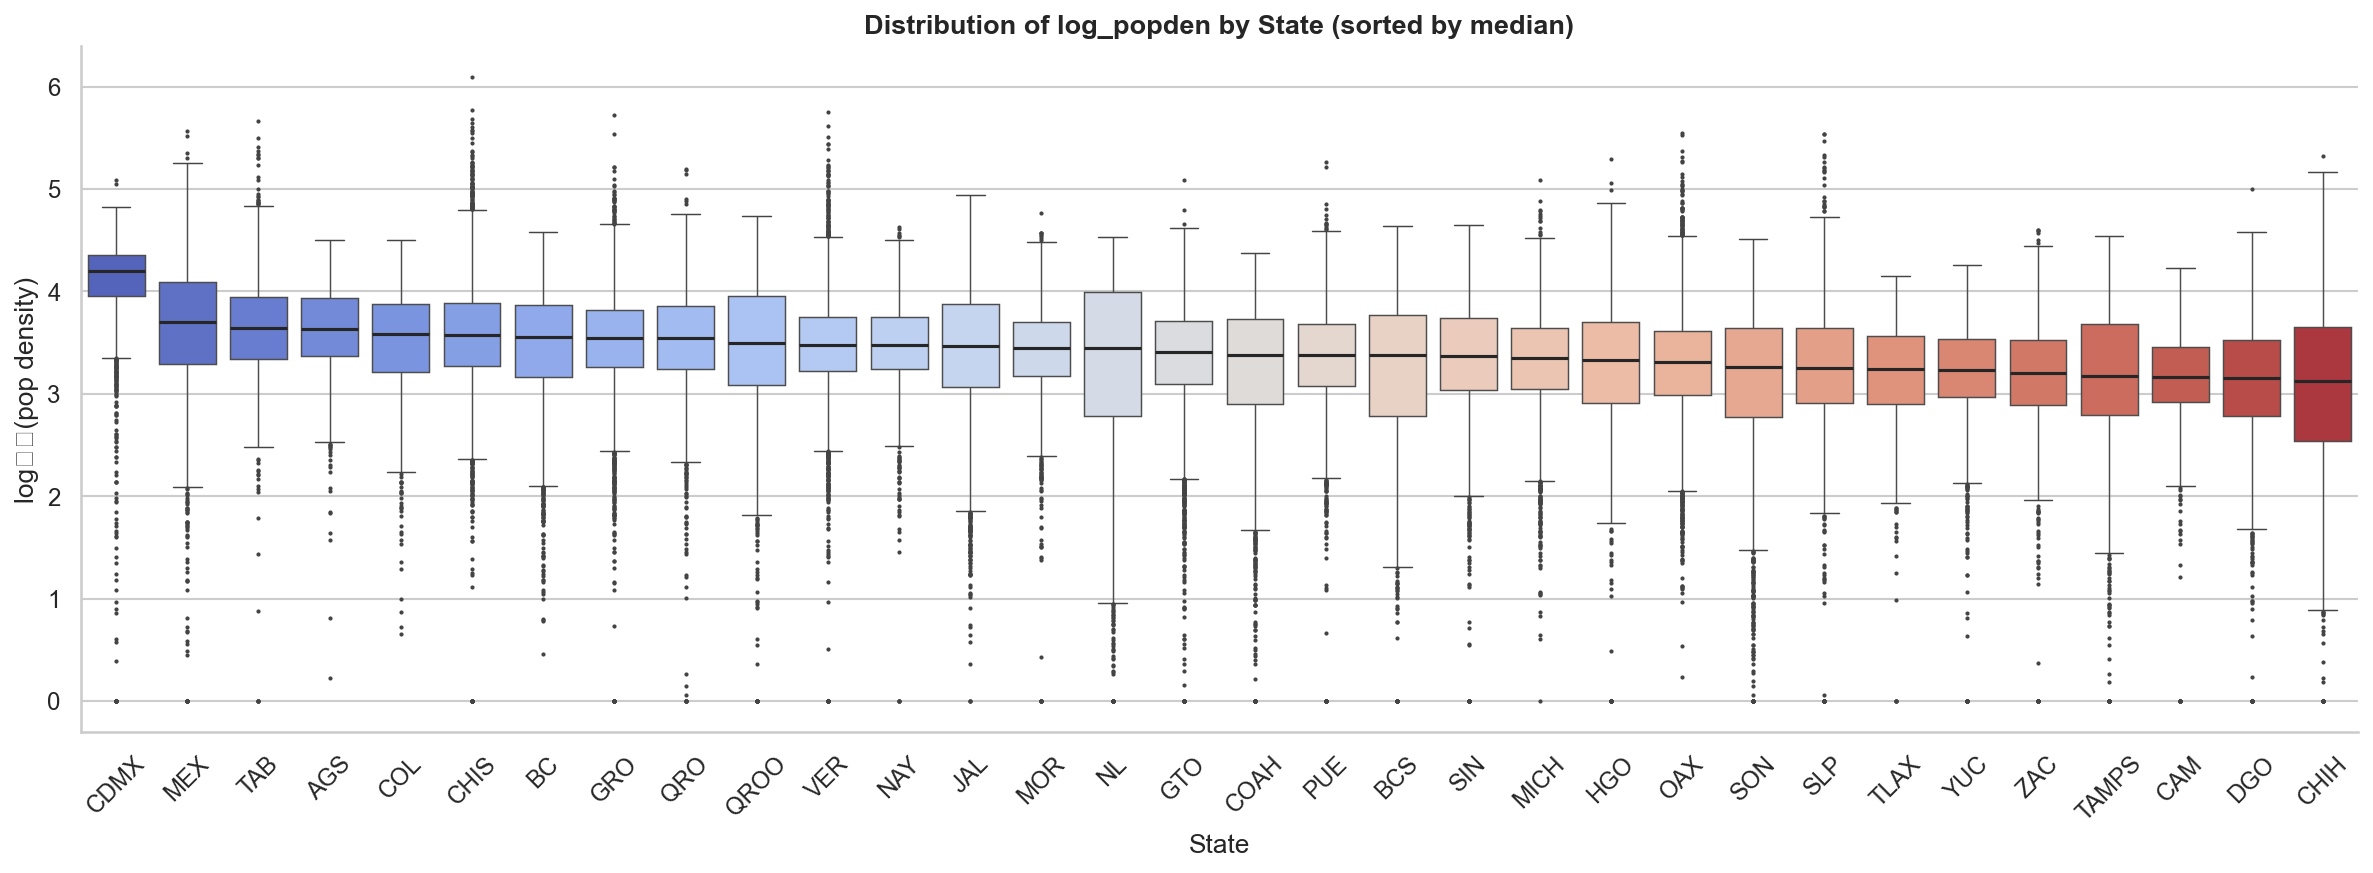

In [18]:
state_names = {
    1: "AGS", 2: "BC", 3: "BCS", 4: "CAM", 5: "COAH", 6: "COL", 7: "CHIS",
    8: "CHIH", 9: "CDMX", 10: "DGO", 11: "GTO", 12: "GRO", 13: "HGO",
    14: "JAL", 15: "MEX", 16: "MICH", 17: "MOR", 18: "NAY", 19: "NL",
    20: "OAX", 21: "PUE", 22: "QRO", 23: "QROO", 24: "SLP", 25: "SIN",
    26: "SON", 27: "TAB", 28: "TAMPS", 29: "TLAX", 30: "VER", 31: "YUC", 32: "ZAC",
}

df["state_abbr"] = df["CVE_ENT"].map(state_names)
state_order = (
    df.groupby("state_abbr")["log_popden"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=df, x="state_abbr", y="log_popden", order=state_order,
            fliersize=1, linewidth=0.7, palette="coolwarm",
            boxprops=dict(edgecolor="0.3"), whiskerprops=dict(color="0.3"),
            medianprops=dict(color="0.15", linewidth=1.5), ax=ax)
ax.set_xlabel("State")
ax.set_ylabel("log₁₀(pop density)")
ax.set_title("Distribution of log_popden by State (sorted by median)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_7.png")
plt.show()

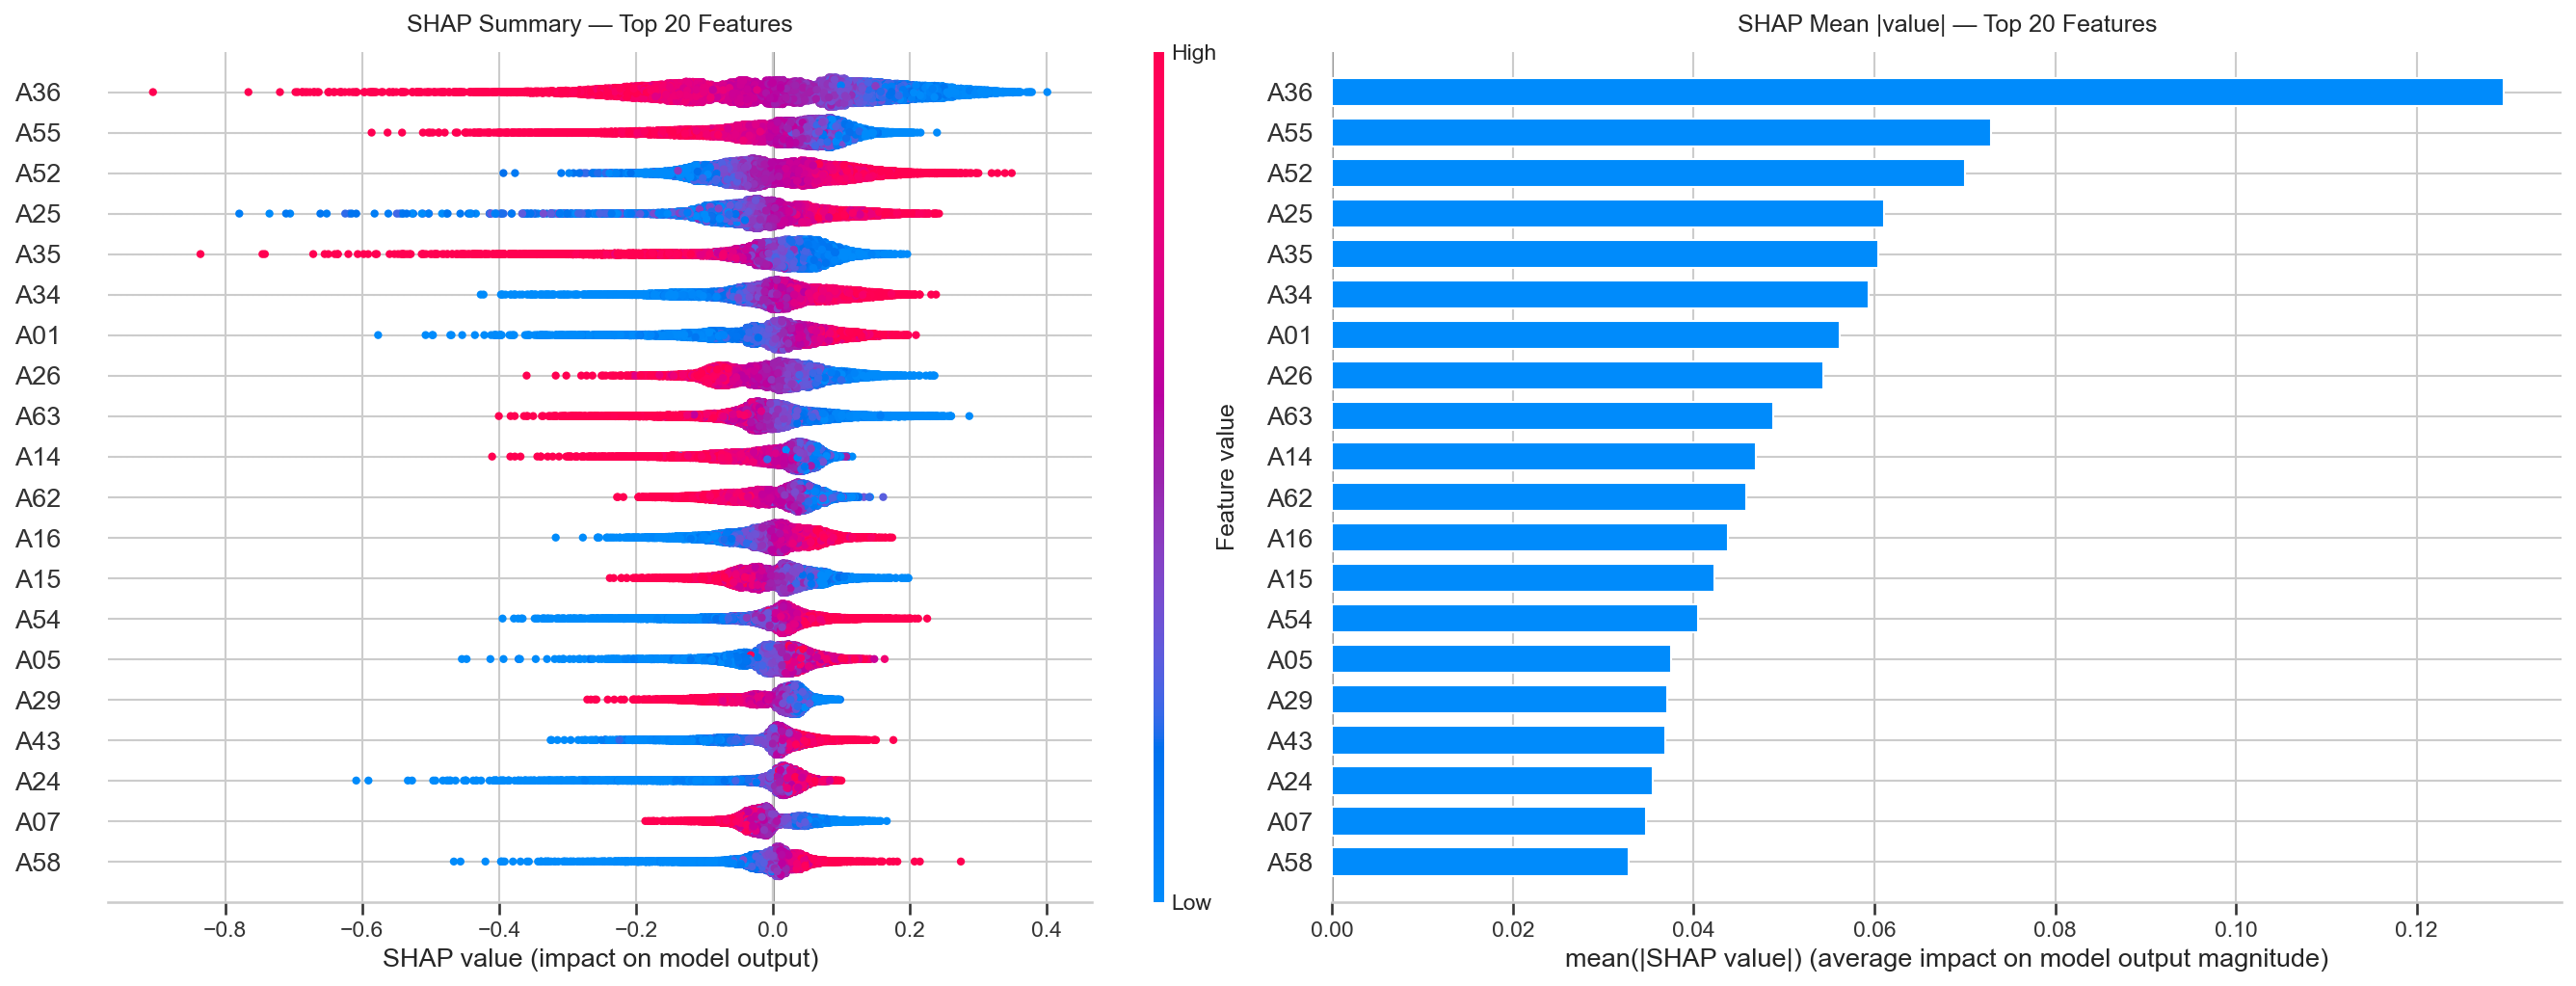

In [19]:
import shap

booster = best_xgb.get_booster()
dtest = xgb.DMatrix(X_test, feature_names=model_features)
shap_values = booster.predict(dtest, pred_contribs=True)
shap_values = shap_values[:, :-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test.values, feature_names=model_features,
                  plot_size=None, show=False, max_display=20)
axes[0].set_title("SHAP Summary — Top 20 Features", fontsize=12, pad=10)

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test.values, feature_names=model_features,
                  plot_type="bar", plot_size=None, show=False, max_display=20)
axes[1].set_title("SHAP Mean |value| — Top 20 Features", fontsize=12, pad=10)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_8.png")
plt.show()

## Experiment: Filtering Out Zero-Value Rows

Many `log_popden` and `log_POBTOT` values are exactly 0 (originally `inf`/`NaN` rows that were filled with 0 during preprocessing). These likely represent AGEBs with missing or zero population/area and can distort the regression. Below we remove those rows and re-run all three models to see if performance improves.

In [22]:
results_full = {}
for name, y_pred in preds.items():
    r2 = r2_score(y_test_den, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_den, y_pred))
    mae = mean_absolute_error(y_test_den, y_pred)
    results_full[name] = {"R²": r2, "RMSE": rmse, "MAE": mae}

comparison_rows = []
for model in ["Ridge", "Random Forest", "XGBoost (default)", "XGBoost (tuned)"]:
    full = results_full.get(model, {})
    filt = results_filtered.get(model, {})
    comparison_rows.append({
        "Model": model,
        "R² (full)": full.get("R²", np.nan),
        "R² (filtered)": filt.get("R²", np.nan),
        "Δ R²": filt.get("R²", 0) - full.get("R²", 0),
        "RMSE (full)": full.get("RMSE", np.nan),
        "RMSE (filtered)": filt.get("RMSE", np.nan),
        "MAE (full)": full.get("MAE", np.nan),
        "MAE (filtered)": filt.get("MAE", np.nan),
    })

comp_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comp_df.style.format("{:.4f}").background_gradient(
    subset=["Δ R²"], cmap="RdYlGn", vmin=-0.05, vmax=0.15))

,R² (full),R² (filtered),Δ R²,RMSE (full),RMSE (filtered),MAE (full),MAE (filtered)
Model,,,,,,,
Ridge,0.4687,0.6224,0.1536,0.5694,0.3510,0.3387,0.2448
Random Forest,0.5271,0.6713,0.1442,0.5372,0.3275,0.3017,0.2195
XGBoost (default),0.5562,0.6972,0.1410,0.5204,0.3143,0.2947,0.2139
XGBoost (tuned),0.5804,0.7250,0.1446,0.5060,0.2995,0.2814,0.2009


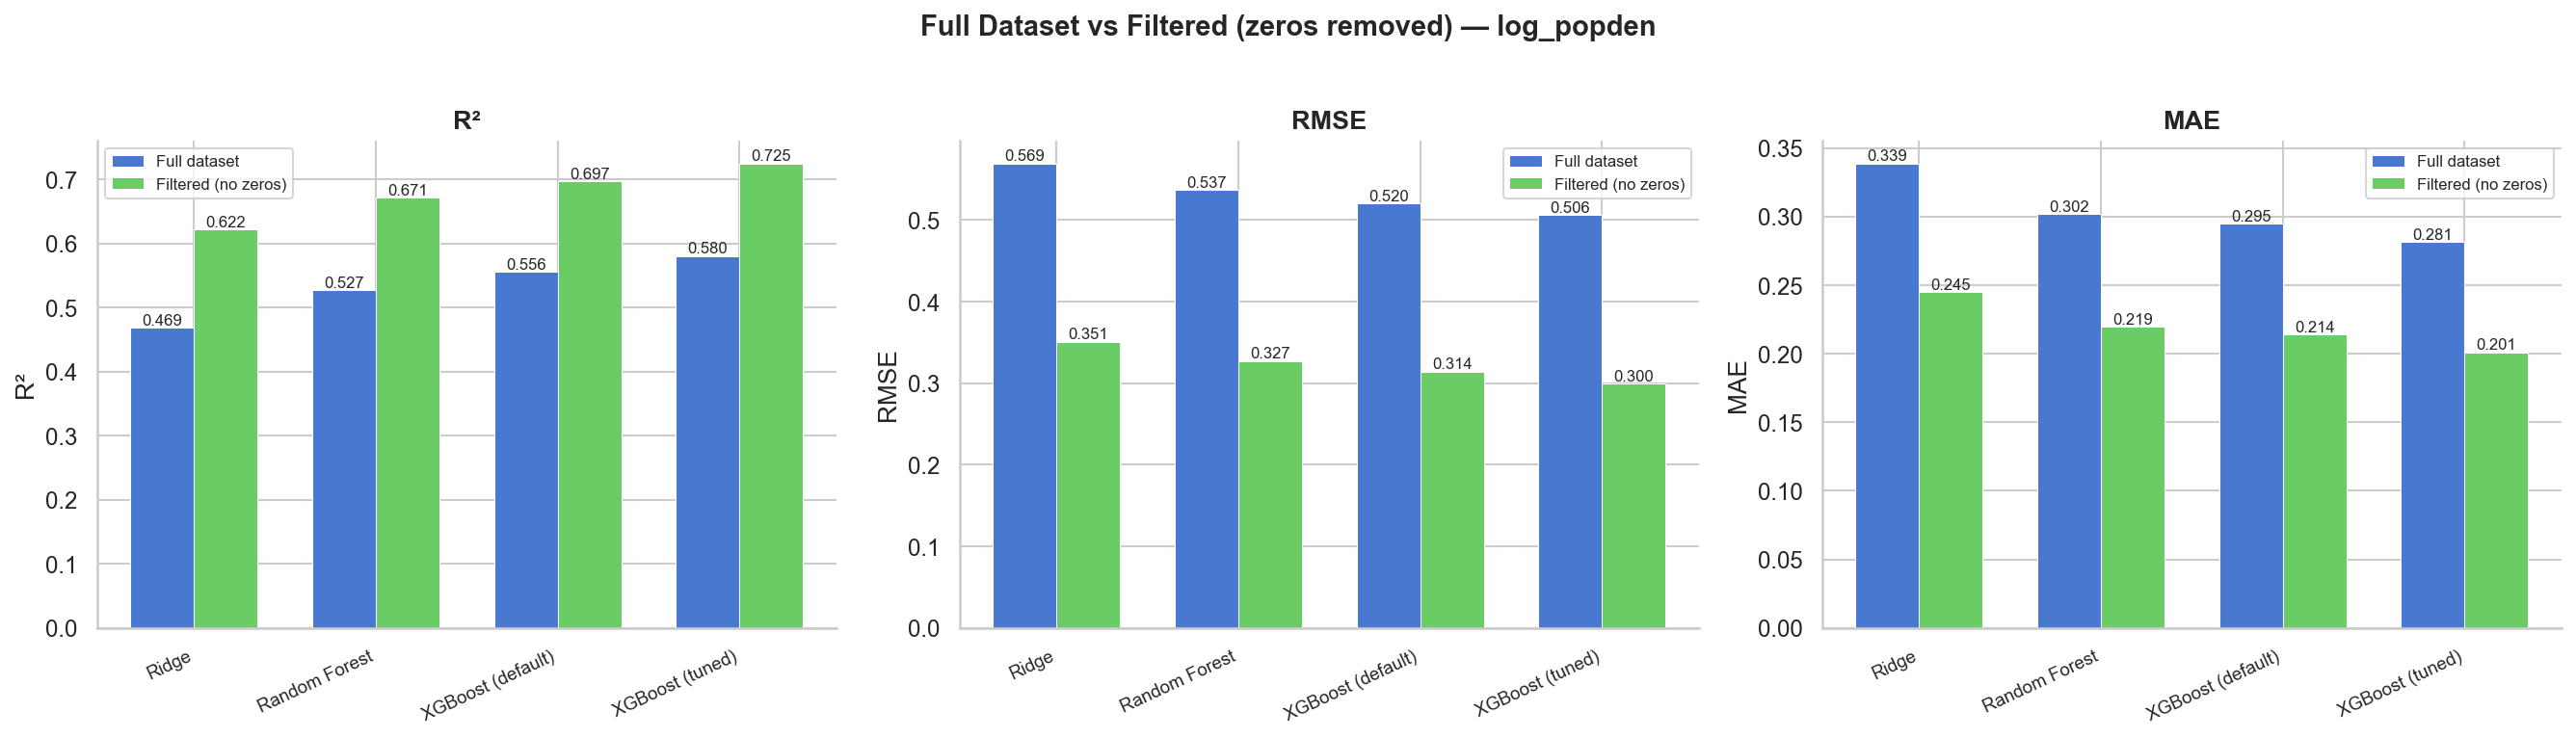

In [23]:
models = ["Ridge", "Random Forest", "XGBoost (default)", "XGBoost (tuned)"]
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ["R²", "RMSE", "MAE"]):
    full_vals = [results_full[m].get(metric, 0) for m in models]
    filt_vals = [results_filtered[m].get(metric, 0) for m in models]

    bars1 = ax.bar(x - width / 2, full_vals, width, label="Full dataset",
                   color=pal[0], edgecolor="white", linewidth=0.5)
    bars2 = ax.bar(x + width / 2, filt_vals, width, label="Filtered (no zeros)",
                   color=pal[2], edgecolor="white", linewidth=0.5)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, frameon=True, fancybox=True)

plt.suptitle("Full Dataset vs Filtered (zeros removed) — log_popden", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_9.png")
plt.show()

## State-wise Performance Analysis

Evaluate how the tuned XGBoost model performs across individual states. This reveals whether the model systematically fails in certain geographic contexts (e.g., highly urban CDMX vs. rural northern states) and whether prediction errors are consistent across density regimes.

In [24]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

state_names = {
    1: "AGS", 2: "BC", 3: "BCS", 4: "CAM", 5: "COAH", 6: "COL", 7: "CHIS",
    8: "CHIH", 9: "CDMX", 10: "DGO", 11: "GTO", 12: "GRO", 13: "HGO",
    14: "JAL", 15: "MEX", 16: "MICH", 17: "MOR", 18: "NAY", 19: "NL",
    20: "OAX", 21: "PUE", 22: "QRO", 23: "QROO", 24: "SLP", 25: "SIN",
    26: "SON", 27: "TAB", 28: "TAMPS", 29: "TLAX", 30: "VER", 31: "YUC", 32: "ZAC",
}

test_idx = Xf_test.index
test_states = df.loc[test_idx, "CVE_ENT"].map(state_names)

y_pred_state = xgb_tuned_f.predict(Xf_test)
residuals_state = yf_test_den.values - y_pred_state

state_metrics = []
for state in sorted(test_states.unique()):
    mask = test_states == state
    y_true_s = yf_test_den.values[mask]
    y_pred_s = y_pred_state[mask]
    n = mask.sum()
    if n < 5:
        continue
    state_metrics.append({
        "State": state,
        "N": n,
        "R²": r2_score(y_true_s, y_pred_s),
        "RMSE": np.sqrt(mean_squared_error(y_true_s, y_pred_s)),
        "MAE": mean_absolute_error(y_true_s, y_pred_s),
        "Mean Residual": np.mean(y_true_s - y_pred_s),
        "Median log_popden": np.median(y_true_s),
    })

state_df = pd.DataFrame(state_metrics).set_index("State").sort_values("R²", ascending=False)
display(state_df.style.format({
    "R²": "{:.3f}", "RMSE": "{:.3f}", "MAE": "{:.3f}",
    "Mean Residual": "{:+.3f}", "Median log_popden": "{:.2f}", "N": "{:,}"
}).background_gradient(subset=["R²"], cmap="RdYlGn", vmin=0.3, vmax=0.85))

,N,R²,RMSE,MAE,Mean Residual,Median log_popden
State,,,,,,
NL,704,0.804,0.337,0.218,-0.001,3.48
TLAX,174,0.775,0.229,0.159,-0.035,3.21
TAMPS,721,0.766,0.292,0.193,+0.004,3.25
HGO,713,0.759,0.262,0.188,-0.026,3.36
QROO,250,0.750,0.307,0.203,+0.031,3.55
BC,461,0.739,0.326,0.214,-0.040,3.53
COAH,553,0.739,0.324,0.217,+0.018,3.42
CHIH,788,0.737,0.337,0.230,+0.005,3.13
PUE,895,0.737,0.251,0.181,+0.013,3.38


/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2434377113.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2434377113.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2434377113.py:29: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_10.png")
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/2434377113.py:29: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_10.png")
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pyl

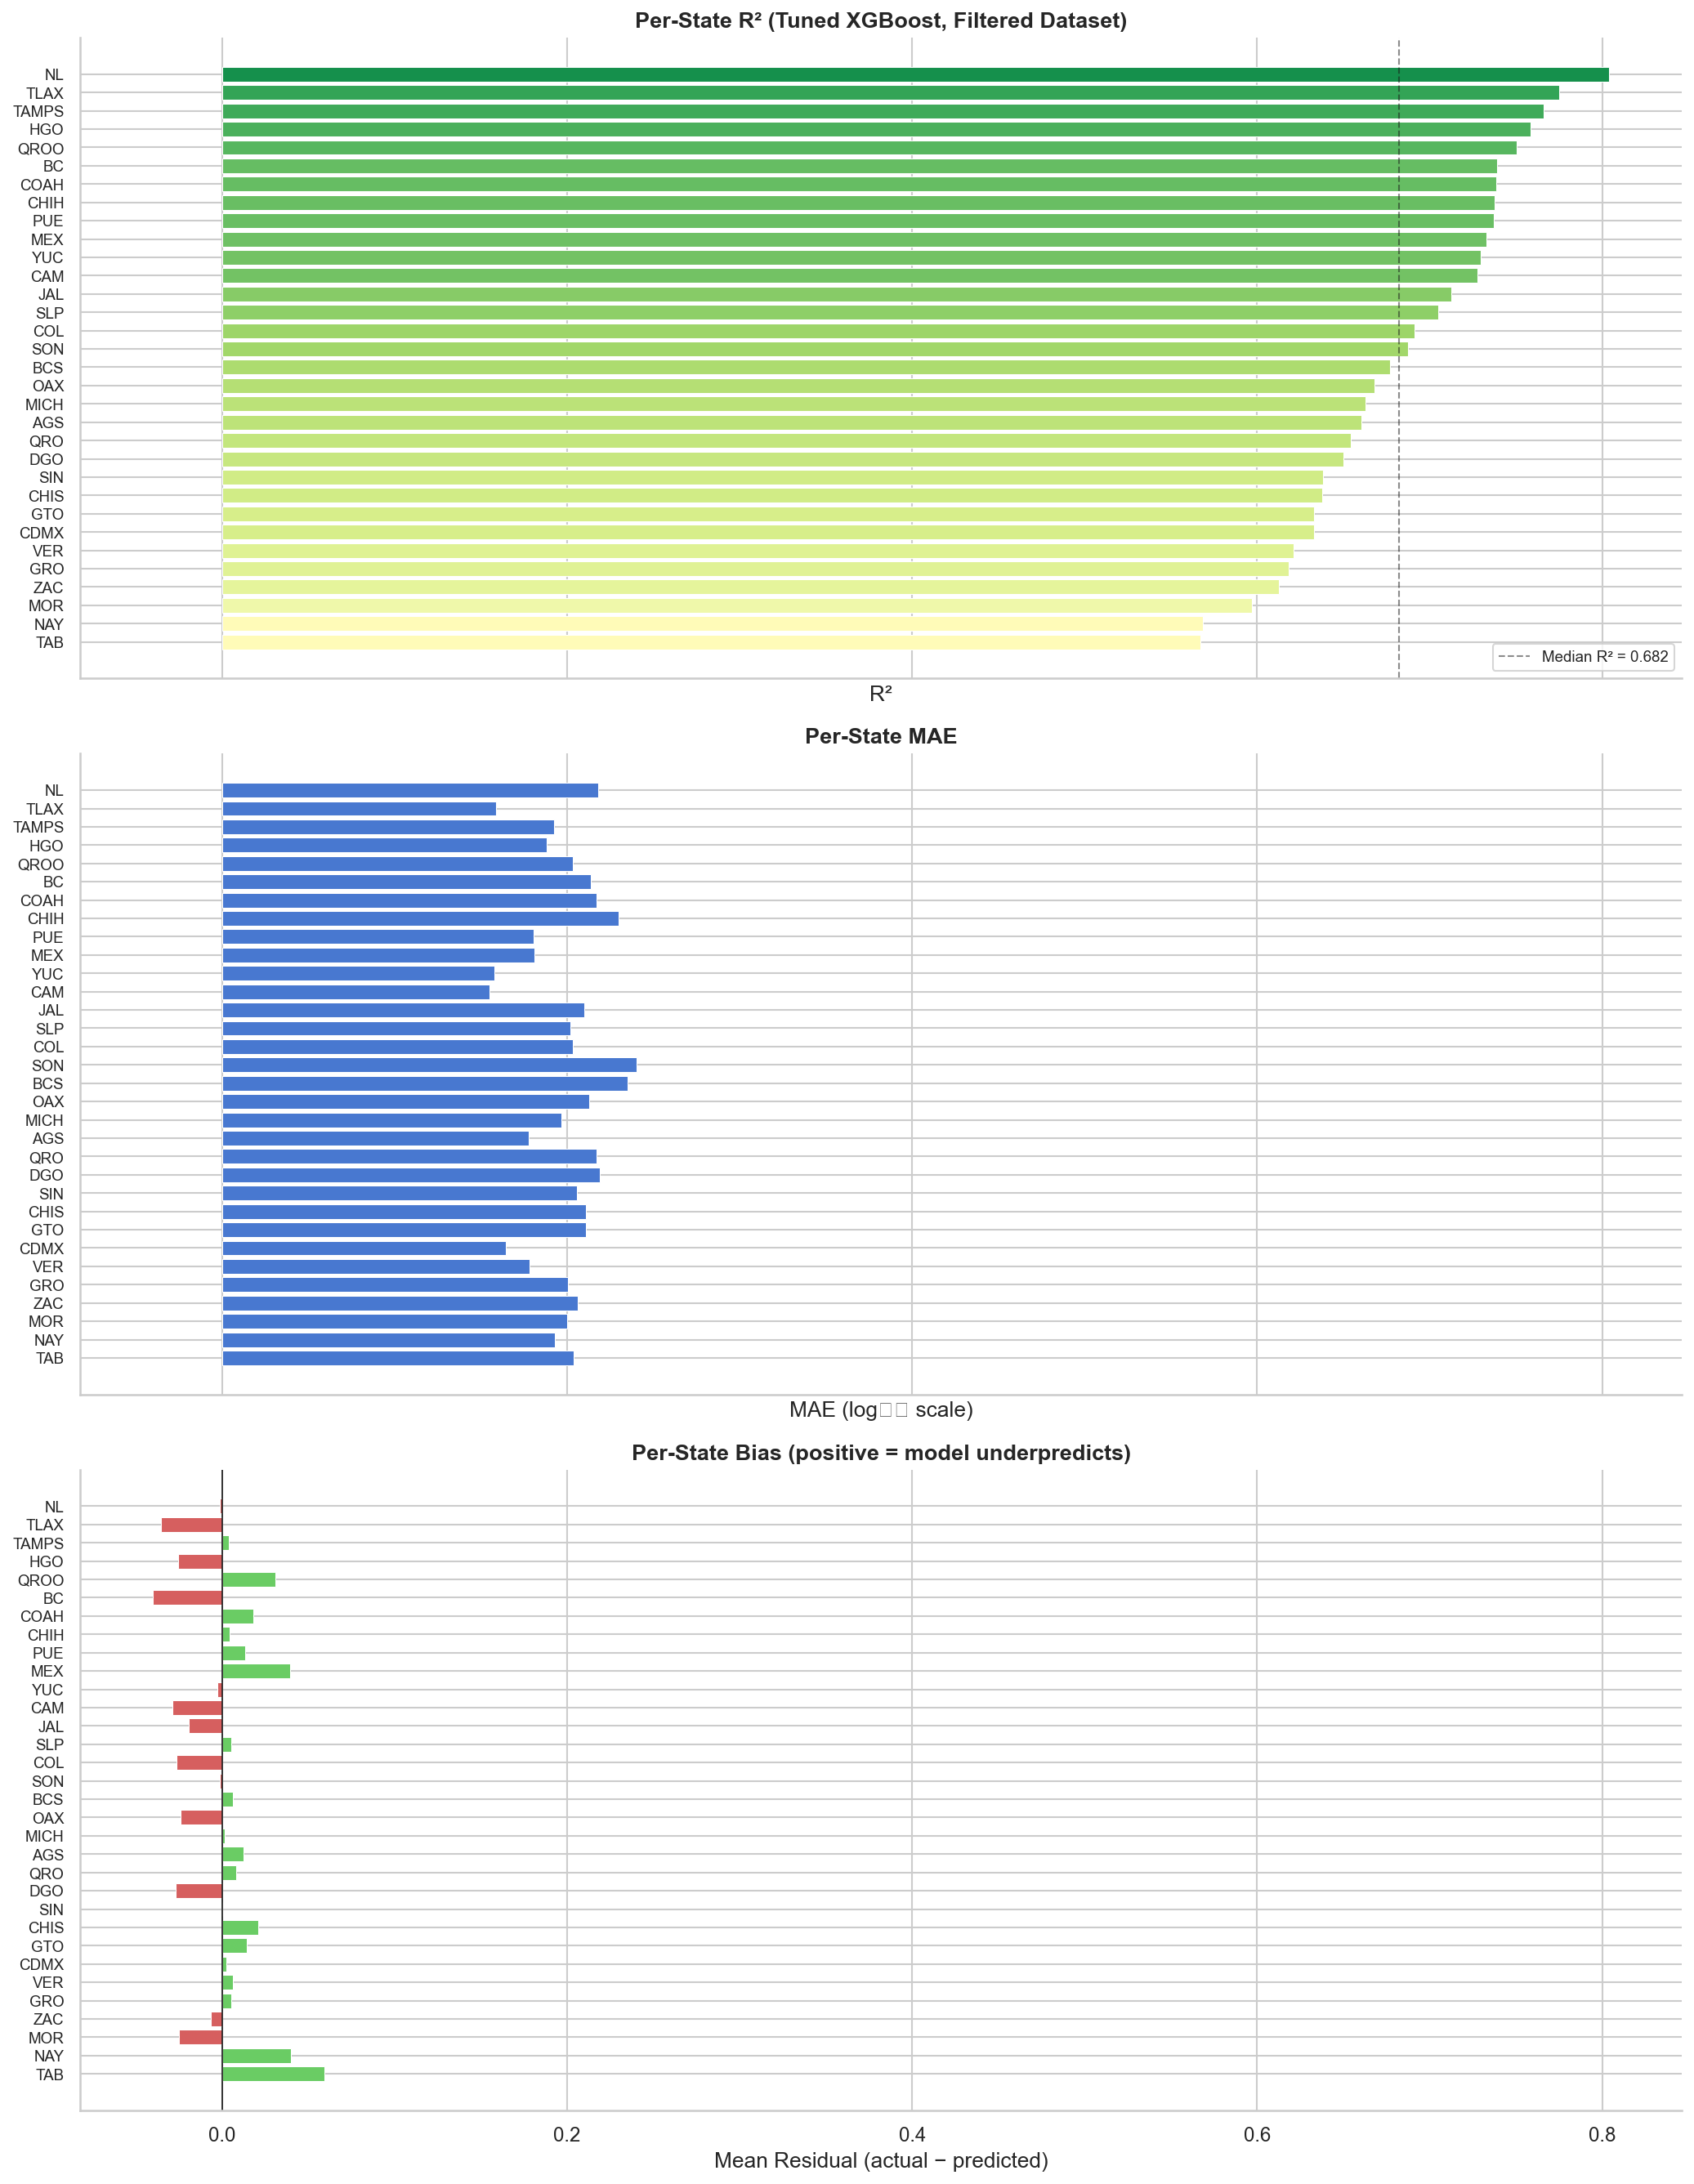

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

state_order = state_df.sort_values("R²", ascending=True).index
r2_norm = (state_df.loc[state_order, "R²"] - 0.3) / 0.55
bar_colors = plt.cm.RdYlGn(r2_norm.clip(0, 1))

axes[0].barh(state_order, state_df.loc[state_order, "R²"], color=bar_colors, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("R²")
axes[0].set_title("Per-State R² (Tuned XGBoost, Filtered Dataset)", fontsize=13, fontweight="bold")
med_r2 = state_df["R²"].median()
axes[0].axvline(med_r2, color="k", ls="--", lw=1, alpha=0.5, label=f"Median R² = {med_r2:.3f}")
axes[0].legend(fontsize=9, frameon=True, fancybox=True)

axes[1].barh(state_order, state_df.loc[state_order, "MAE"], color=pal[0], edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("MAE (log₁₀ scale)")
axes[1].set_title("Per-State MAE", fontsize=13, fontweight="bold")

bias_colors = [pal[3] if v < 0 else pal[2] for v in state_df.loc[state_order, "Mean Residual"]]
axes[2].barh(state_order, state_df.loc[state_order, "Mean Residual"],
             color=bias_colors, edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="k", ls="-", lw=0.8)
axes[2].set_xlabel("Mean Residual (actual − predicted)")
axes[2].set_title("Per-State Bias (positive = model underpredicts)", fontsize=13, fontweight="bold")

for ax in axes:
    ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_10.png")
plt.show()

### Calibration: Error Consistency Across Density Regimes

Check whether the model's prediction errors are consistent across low-, medium-, and high-density AGEBs, or whether certain density regimes are systematically harder to predict.

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/970935758.py:56: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/970935758.py:56: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/970935758.py:57: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_11.png")
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_79526/970935758.py:57: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(f"{FIGURES_DIR}/fig_11.png")
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabto

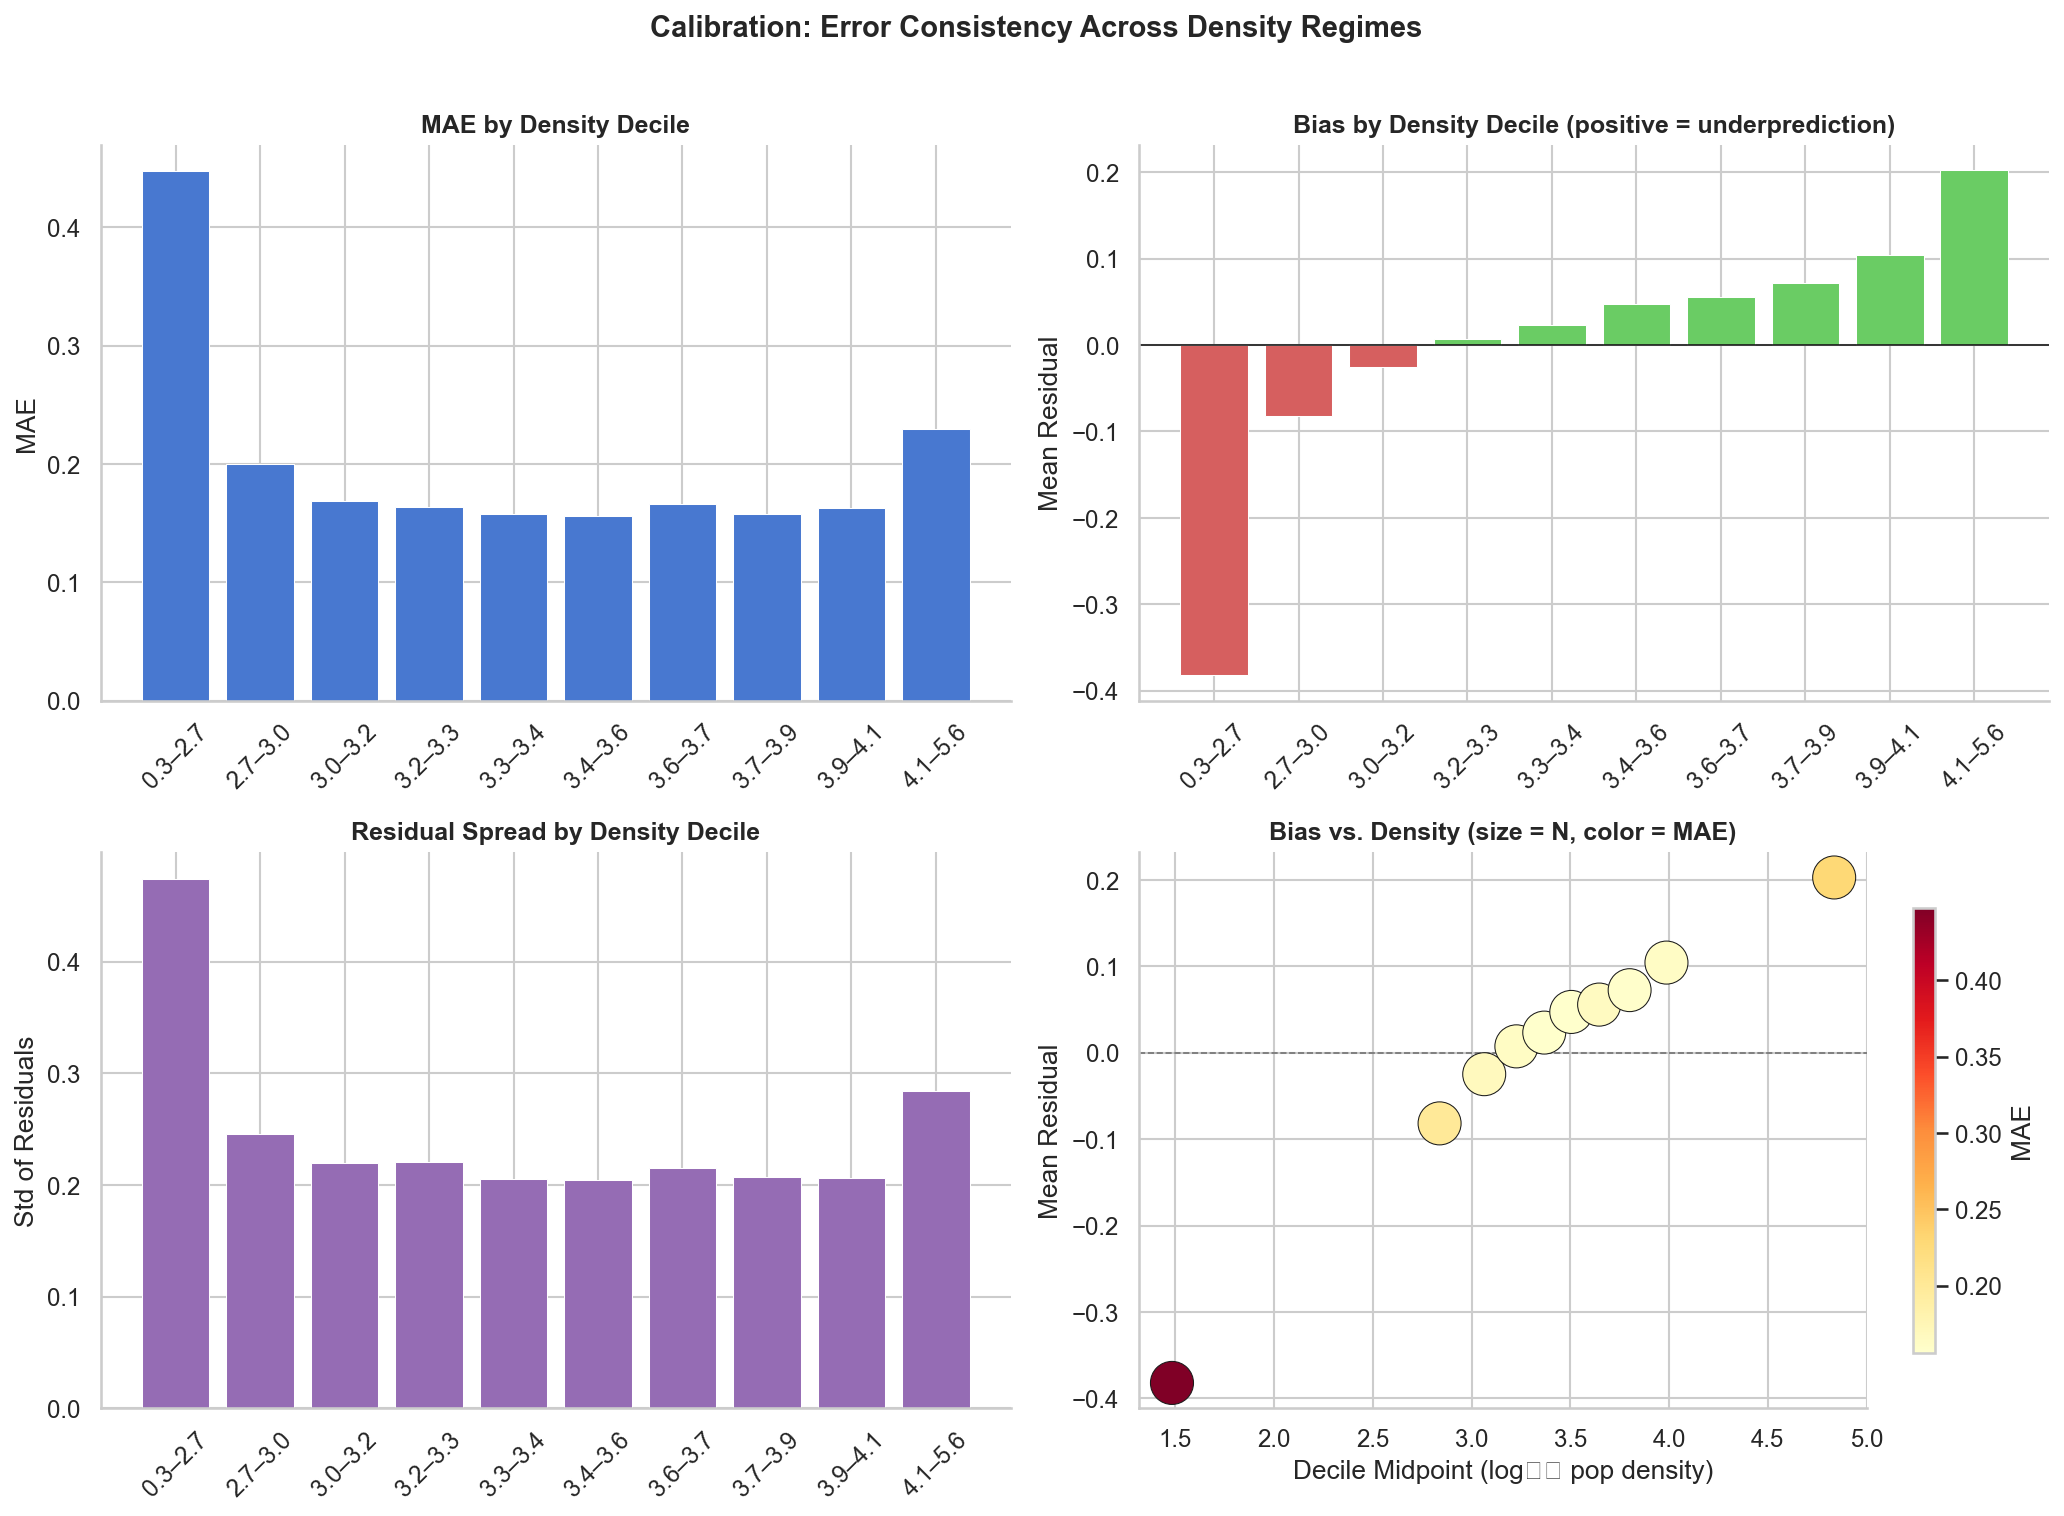


Calibration summary table:


,N,R²,RMSE,MAE,Mean Residual,Std Residual
Bin,,,,,,
0.3–2.7,"2,136",-1.142,0.609,0.447,-0.3822,0.475
2.7–3.0,"2,132",-10.316,0.259,0.200,-0.0818,0.246
3.0–3.2,"2,127",-17.082,0.221,0.168,-0.0248,0.220
3.2–3.3,"2,136",-26.568,0.221,0.164,+0.0074,0.221
3.3–3.4,"2,126",-26.244,0.207,0.157,+0.0233,0.206
3.4–3.6,"2,134",-26.348,0.210,0.156,+0.0472,0.205
3.6–3.7,"2,137",-28.898,0.223,0.166,+0.0557,0.216
3.7–3.9,"2,122",-20.894,0.219,0.157,+0.0724,0.207
3.9–4.1,"2,132",-13.994,0.231,0.162,+0.1044,0.206


In [26]:
n_bins = 10
bin_edges = np.quantile(yf_test_den, np.linspace(0, 1, n_bins + 1))
bin_labels = [f"{bin_edges[i]:.1f}–{bin_edges[i+1]:.1f}" for i in range(n_bins)]
bin_idx = np.digitize(yf_test_den, bin_edges, right=True).clip(1, n_bins) - 1

cal_metrics = []
for b in range(n_bins):
    mask = bin_idx == b
    y_true_b = yf_test_den.values[mask]
    y_pred_b = y_pred_state[mask]
    n = mask.sum()
    if n < 10:
        continue
    cal_metrics.append({
        "Bin": bin_labels[b],
        "Bin Mid": (bin_edges[b] + bin_edges[b + 1]) / 2,
        "N": n,
        "R²": r2_score(y_true_b, y_pred_b),
        "RMSE": np.sqrt(mean_squared_error(y_true_b, y_pred_b)),
        "MAE": mean_absolute_error(y_true_b, y_pred_b),
        "Mean Residual": np.mean(y_true_b - y_pred_b),
        "Std Residual": np.std(y_true_b - y_pred_b),
    })

cal_df = pd.DataFrame(cal_metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(cal_df["Bin"], cal_df["MAE"], color=pal[0], edgecolor="white", linewidth=0.5)
axes[0, 0].set_ylabel("MAE")
axes[0, 0].set_title("MAE by Density Decile", fontsize=12, fontweight="bold")
axes[0, 0].tick_params(axis="x", rotation=45)

bias_colors = [pal[3] if v < 0 else pal[2] for v in cal_df["Mean Residual"]]
axes[0, 1].bar(cal_df["Bin"], cal_df["Mean Residual"], color=bias_colors, edgecolor="white", linewidth=0.5)
axes[0, 1].axhline(0, color="k", ls="-", lw=0.8)
axes[0, 1].set_ylabel("Mean Residual")
axes[0, 1].set_title("Bias by Density Decile (positive = underprediction)", fontsize=12, fontweight="bold")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(cal_df["Bin"], cal_df["Std Residual"], color=pal[4], edgecolor="white", linewidth=0.5)
axes[1, 0].set_ylabel("Std of Residuals")
axes[1, 0].set_title("Residual Spread by Density Decile", fontsize=12, fontweight="bold")
axes[1, 0].tick_params(axis="x", rotation=45)

sc = axes[1, 1].scatter(cal_df["Bin Mid"], cal_df["Mean Residual"], s=cal_df["N"] / 5,
                        c=cal_df["MAE"], cmap="YlOrRd", edgecolors="k", linewidth=0.5, zorder=3)
axes[1, 1].axhline(0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[1, 1].set_xlabel("Decile Midpoint (log₁₀ pop density)")
axes[1, 1].set_ylabel("Mean Residual")
axes[1, 1].set_title("Bias vs. Density (size = N, color = MAE)", fontsize=12, fontweight="bold")
cbar = plt.colorbar(sc, ax=axes[1, 1], shrink=0.8)
cbar.set_label("MAE")

plt.suptitle("Calibration: Error Consistency Across Density Regimes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_11.png")
plt.show()

print("\nCalibration summary table:")
display(cal_df.set_index("Bin").drop(columns="Bin Mid").style.format({
    "R²": "{:.3f}", "RMSE": "{:.3f}", "MAE": "{:.3f}",
    "Mean Residual": "{:+.4f}", "Std Residual": "{:.3f}", "N": "{:,}"
}))

### State-Level Choropleth Maps

Visualize the geographic distribution of model performance across Mexico by plotting per-state R², MAE, and bias on a choropleth map.

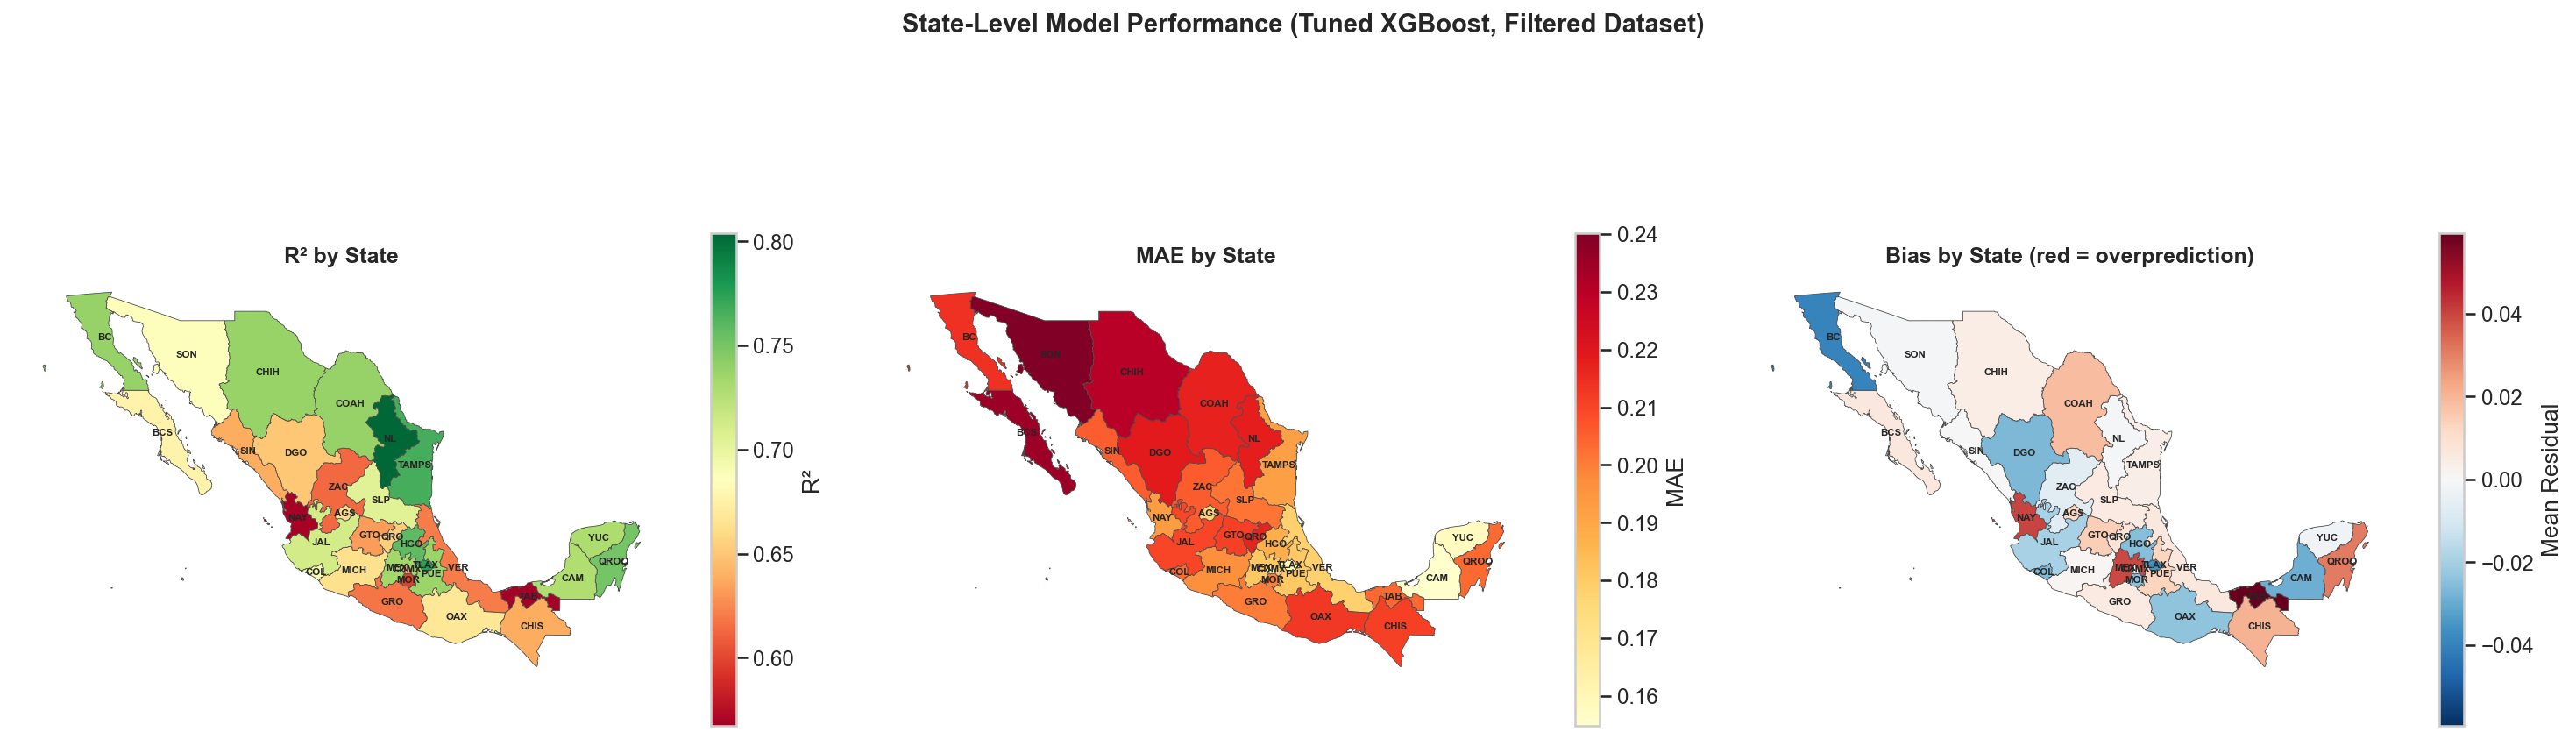

In [27]:
import geopandas as gpd

mexico_states = gpd.read_file(
    "https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json"
)

abbr_to_iso = {
    "AGS": "MX-AGU", "BC": "MX-BCN", "BCS": "MX-BCS", "CAM": "MX-CAM",
    "COAH": "MX-COA", "COL": "MX-COL", "CHIS": "MX-CHP", "CHIH": "MX-CHH",
    "CDMX": "MX-CMX", "DGO": "MX-DUR", "GTO": "MX-GUA", "GRO": "MX-GRO",
    "HGO": "MX-HID", "JAL": "MX-JAL", "MEX": "MX-MEX", "MICH": "MX-MIC",
    "MOR": "MX-MOR", "NAY": "MX-NAY", "NL": "MX-NLE", "OAX": "MX-OAX",
    "PUE": "MX-PUE", "QRO": "MX-QUE", "QROO": "MX-ROO", "SLP": "MX-SLP",
    "SIN": "MX-SIN", "SON": "MX-SON", "TAB": "MX-TAB", "TAMPS": "MX-TAM",
    "TLAX": "MX-TLA", "VER": "MX-VER", "YUC": "MX-YUC", "ZAC": "MX-ZAC",
}

metrics_for_map = state_df.copy()
metrics_for_map["iso"] = metrics_for_map.index.map(abbr_to_iso)
mexico_map = mexico_states.merge(metrics_for_map, left_on="id", right_on="iso", how="left")

plot_specs = [
    ("R²",            "RdYlGn",  "R² by State"),
    ("MAE",           "YlOrRd",  "MAE by State"),
    ("Mean Residual", "RdBu_r",  "Bias by State (red = overprediction)"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (col, cmap, title) in zip(axes, plot_specs):
    kwargs = {}
    if col == "Mean Residual":
        vabs = max(abs(mexico_map[col].min()), abs(mexico_map[col].max()))
        kwargs = {"vmin": -vabs, "vmax": vabs}

    mexico_map.plot(
        column=col, cmap=cmap, linewidth=0.4, edgecolor="0.3",
        legend=True, legend_kwds={"shrink": 0.6, "label": col},
        ax=ax, missing_kwds={"color": "lightgrey"}, **kwargs,
    )
    for _, row in mexico_map.dropna(subset=[col]).iterrows():
        centroid = row.geometry.centroid
        abbr = row["name"][:3].upper()
        matched = [k for k, v in abbr_to_iso.items() if v == row["id"]]
        label = matched[0] if matched else abbr
        ax.annotate(label, xy=(centroid.x, centroid.y),
                    ha="center", va="center", fontsize=5.5, fontweight="bold",
                    color="0.15")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("State-Level Model Performance (Tuned XGBoost, Filtered Dataset)",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_12.png")
plt.show()

### What Drives State-Level Performance Differences?

Investigate which state-level data characteristics (sample size, target variance, urban/rural mix, area, zero-population fraction) correlate with per-state R², to understand why the model performs better in some states than others.

In [28]:
from scipy.stats import pearsonr

grouped = df.groupby("state_abbr")

state_chars = pd.DataFrame({
    "N": grouped.size(),
    "target_var": grouped["log_popden"].var(),
    "frac_zero": grouped["log_popden"].apply(lambda s: (s == 0).mean()),
    "mean_area": grouped["area_sqkm"].mean(),
    "median_area": grouped["area_sqkm"].median(),
    "frac_urban": grouped["CVEGEO"].apply(lambda s: (s.astype(str).str.len() == 13).mean()),
})

state_chars["R²"] = state_df["R²"]
state_chars = state_chars.dropna(subset=["R²"])

display(state_chars.sort_values("R²", ascending=False).style.format({
    "R²": "{:.3f}", "target_var": "{:.3f}", "frac_zero": "{:.3f}",
    "mean_area": "{:.2f}", "median_area": "{:.3f}", "frac_urban": "{:.3f}", "N": "{:,}",
}))

,N,target_var,frac_zero,mean_area,median_area,frac_urban,R²
state_abbr,,,,,,,
NL,"3,717",0.891,0.028,0.41,0.299,0.744,0.804
TLAX,895,0.288,0.004,0.82,0.589,0.746,0.775
TAMPS,"3,676",0.671,0.030,0.35,0.260,0.664,0.766
HGO,"3,661",0.344,0.004,0.58,0.240,0.392,0.759
QROO,"1,372",0.750,0.028,0.35,0.243,0.754,0.750
BC,"2,275",0.365,0.000,0.45,0.331,0.781,0.739
COAH,"2,659",0.601,0.016,0.41,0.297,0.708,0.739
CHIH,"4,126",0.823,0.042,0.41,0.268,0.700,0.737
PUE,"4,568",0.249,0.002,0.55,0.347,0.546,0.737


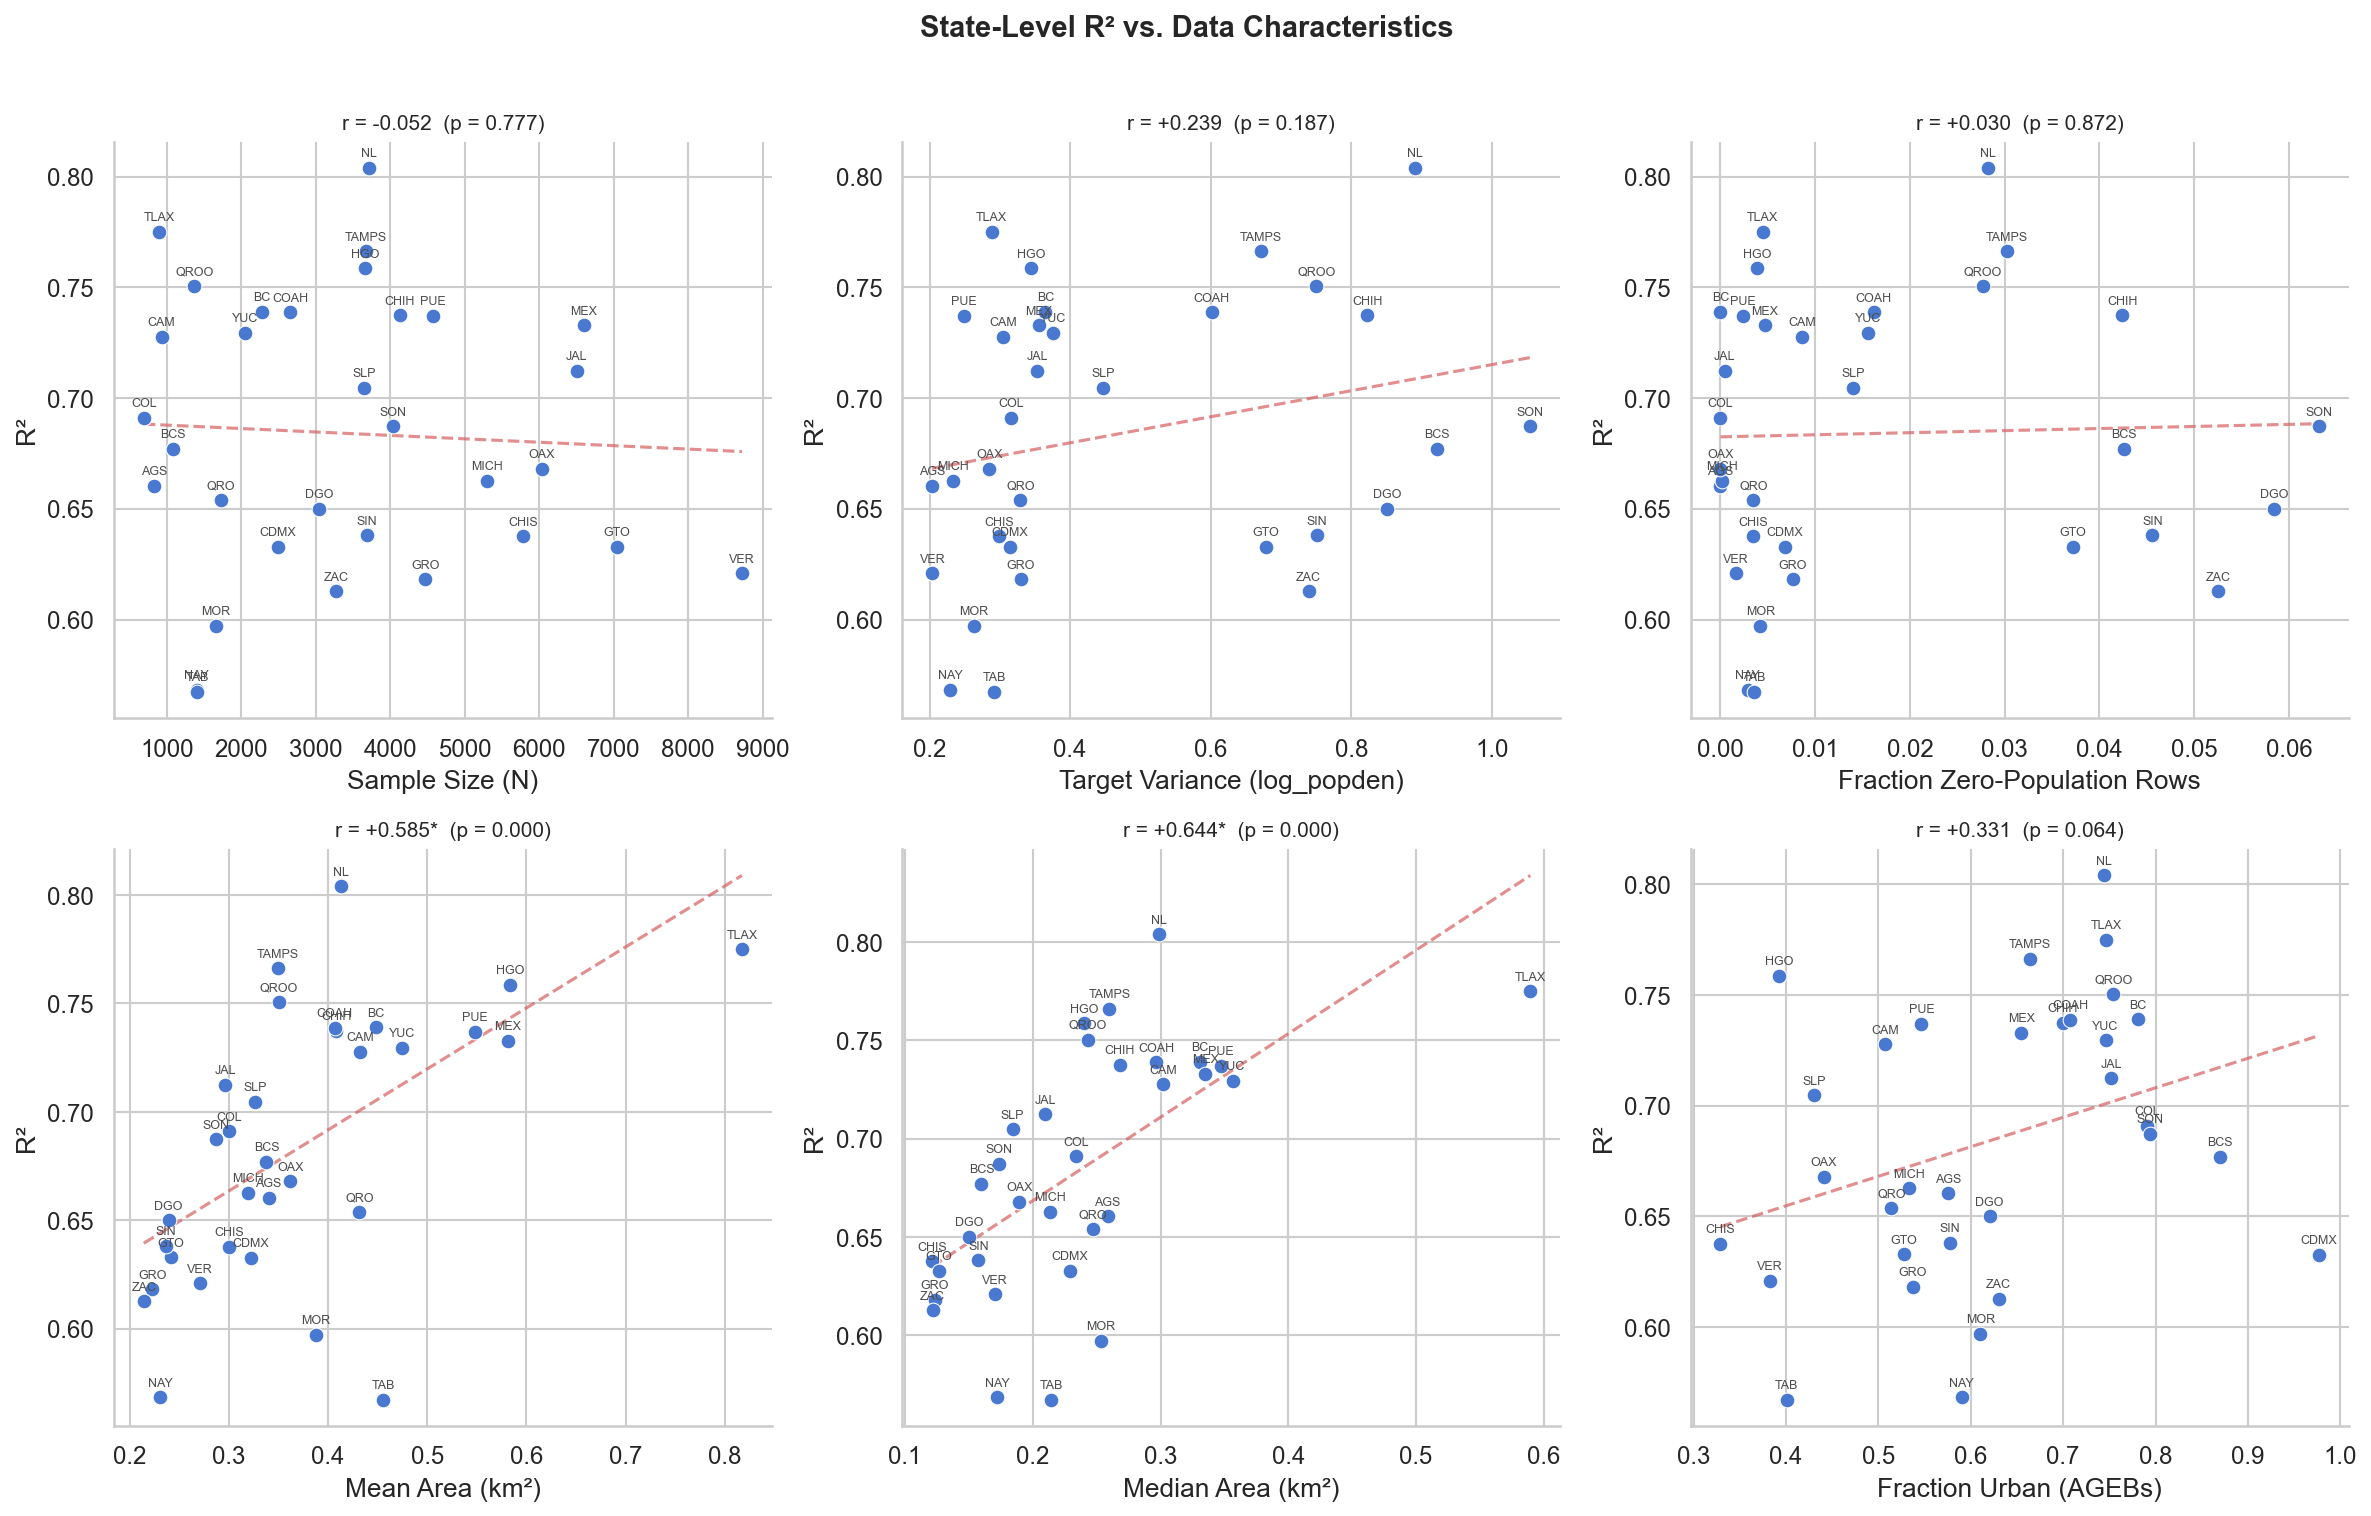

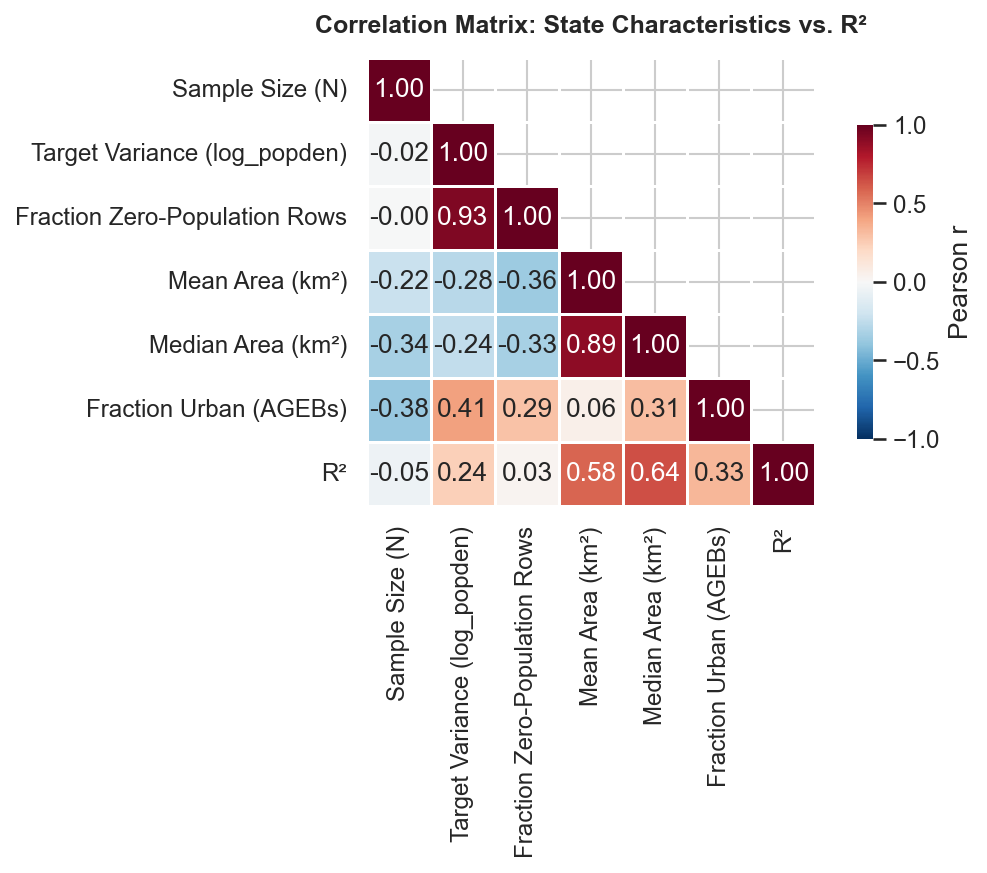

In [29]:
feature_cols = ["N", "target_var", "frac_zero", "mean_area", "median_area", "frac_urban"]
feature_labels = {
    "N": "Sample Size (N)",
    "target_var": "Target Variance (log_popden)",
    "frac_zero": "Fraction Zero-Population Rows",
    "mean_area": "Mean Area (km²)",
    "median_area": "Median Area (km²)",
    "frac_urban": "Fraction Urban (AGEBs)",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flat, feature_cols):
    x = state_chars[col].values
    y = state_chars["R²"].values
    ax.scatter(x, y, s=50, color=pal[0], edgecolor="white", linewidth=0.5, zorder=3)

    for state, row in state_chars.iterrows():
        ax.annotate(state, (row[col], row["R²"]),
                    fontsize=6, ha="center", va="bottom", color="0.3",
                    xytext=(0, 4), textcoords="offset points")

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_line, m * x_line + b, color=pal[3], linewidth=1.5, ls="--", alpha=0.7)

    r, p = pearsonr(x, y)
    ax.set_xlabel(feature_labels[col])
    ax.set_ylabel("R²")
    sig = "*" if p < 0.05 else ""
    ax.set_title(f"r = {r:+.3f}{sig}  (p = {p:.3f})", fontsize=10)

plt.suptitle("State-Level R² vs. Data Characteristics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_13a.png")
plt.show()

# Correlation heatmap
corr_cols = feature_cols + ["R²"]
corr_matrix = state_chars[corr_cols].rename(columns=feature_labels).corr()

fig2, ax2 = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax2)
ax2.set_title("Correlation Matrix: State Characteristics vs. R²", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
fig2.savefig(f"{FIGURES_DIR}/fig_13b.png")
plt.show()

#### Performance by Polygon Type: Urban AGEBs vs. Rural Localities

Split each state's test set into urban AGEBs (13-digit CVEGEO) and rural localities (9-digit CVEGEO) to determine whether one polygon type is systematically harder to predict.

In [30]:
test_cvegeo = df.loc[Xf_test.index, "CVEGEO"].astype(str)
poly_type = test_cvegeo.str.len().map({13: "AGEB", 9: "Locality"})

split_df = pd.DataFrame({
    "state": test_states.values,
    "poly_type": poly_type.values,
    "y_true": yf_test_den.values,
    "y_pred": y_pred_state,
}, index=Xf_test.index).dropna(subset=["poly_type"])

rows = []
for (state, ptype), grp in split_df.groupby(["state", "poly_type"]):
    if len(grp) < 10:
        continue
    rows.append({
        "State": state,
        "Type": ptype,
        "R²": r2_score(grp["y_true"], grp["y_pred"]),
        "N": len(grp),
    })

type_df = pd.DataFrame(rows)

pivot_r2 = type_df.pivot(index="State", columns="Type", values="R²")
pivot_n = type_df.pivot(index="State", columns="Type", values="N")
ageb_loc_df = pd.DataFrame({
    "R²_AGEB": pivot_r2.get("AGEB"),
    "R²_Locality": pivot_r2.get("Locality"),
    "N_AGEB": pivot_n.get("AGEB"),
    "N_Locality": pivot_n.get("Locality"),
}).dropna()
ageb_loc_df["R²_Gap"] = ageb_loc_df["R²_AGEB"] - ageb_loc_df["R²_Locality"]
ageb_loc_df = ageb_loc_df.sort_values("R²_Gap", ascending=False)

display(ageb_loc_df.style.format({
    "R²_AGEB": "{:.3f}", "R²_Locality": "{:.3f}",
    "N_AGEB": "{:,.0f}", "N_Locality": "{:,.0f}", "R²_Gap": "{:+.3f}"
}).background_gradient(subset=["R²_Gap"], cmap="RdYlGn", vmin=-0.5, vmax=0.5))

,R²_AGEB,R²_Locality,N_AGEB,N_Locality,R²_Gap
State,,,,,
BCS,0.719,-0.264,164,31,+0.983
NAY,0.670,0.262,139,116,+0.409
BC,0.687,0.368,345,116,+0.318
GRO,0.730,0.413,469,414,+0.318
MEX,0.786,0.485,839,473,+0.301
CDMX,0.629,0.348,510,11,+0.281
ZAC,0.653,0.375,355,229,+0.278
MOR,0.658,0.385,220,114,+0.273
NL,0.762,0.517,524,180,+0.245


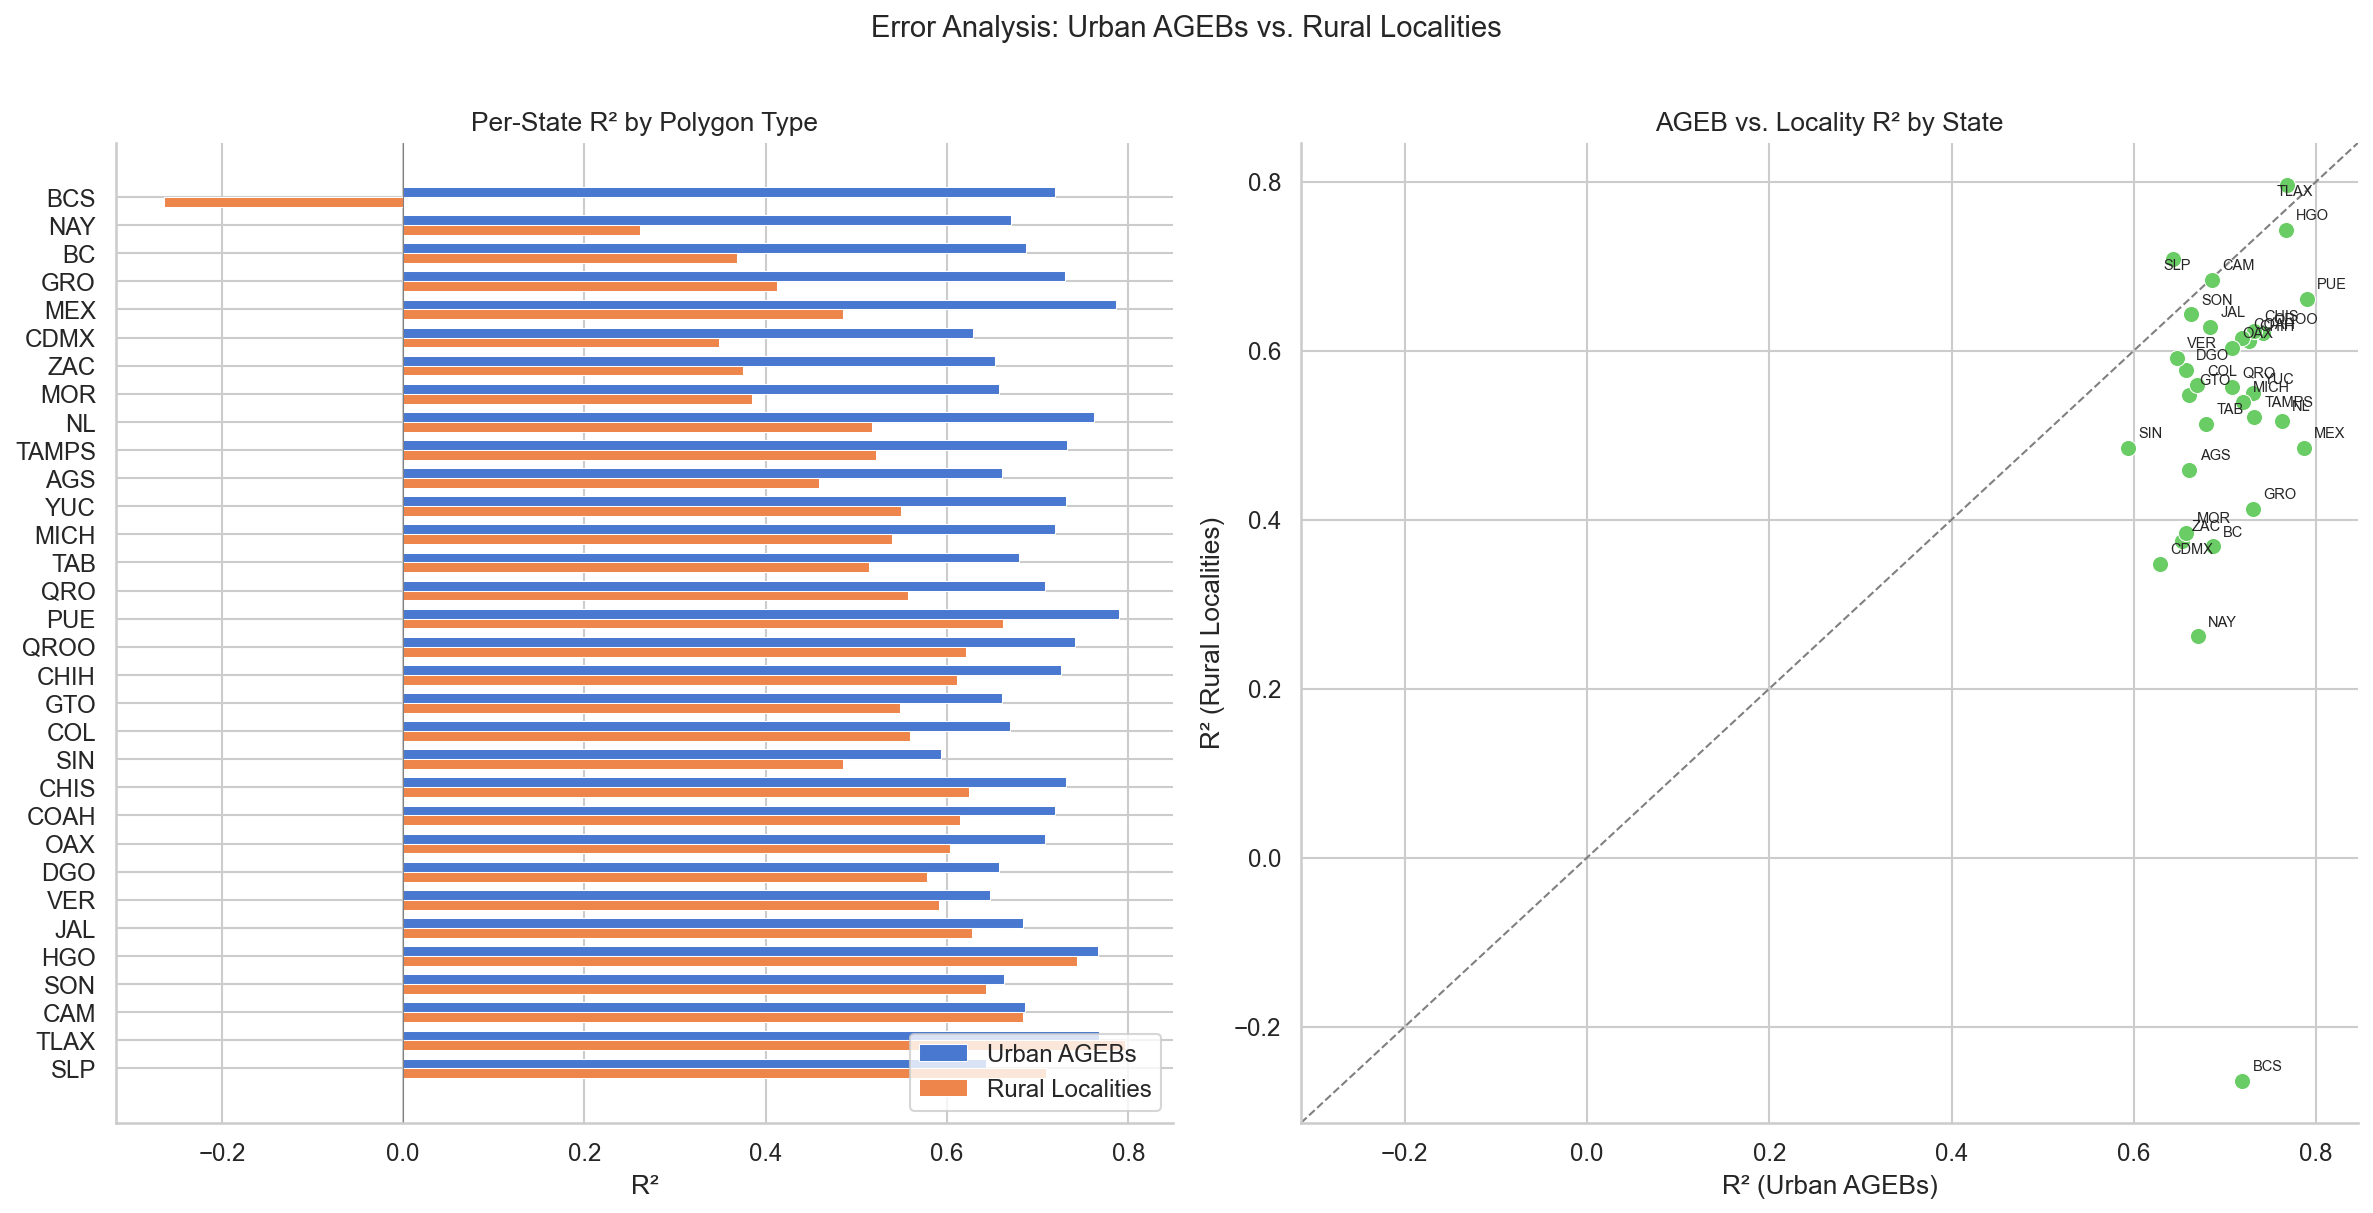

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

plot_df = ageb_loc_df.sort_values("R²_Gap", ascending=True)
y_pos = np.arange(len(plot_df))
width = 0.35

ax1.barh(y_pos + width / 2, plot_df["R²_AGEB"], width,
         label="Urban AGEBs", color=pal[0], edgecolor="white", linewidth=0.5)
ax1.barh(y_pos - width / 2, plot_df["R²_Locality"], width,
         label="Rural Localities", color=pal[1], edgecolor="white", linewidth=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_df.index)
ax1.set_xlabel("R²")
ax1.set_title("Per-State R² by Polygon Type")
ax1.legend(loc="lower right")
ax1.axvline(0, color="grey", linewidth=0.5)

ax2.scatter(ageb_loc_df["R²_AGEB"], ageb_loc_df["R²_Locality"],
            s=60, color=pal[2], edgecolor="white", linewidth=0.5, zorder=3)
lims = [min(ageb_loc_df[["R²_AGEB", "R²_Locality"]].min()) - 0.05,
        max(ageb_loc_df[["R²_AGEB", "R²_Locality"]].max()) + 0.05]
ax2.plot(lims, lims, "--", color="grey", linewidth=1, zorder=1)
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel("R² (Urban AGEBs)")
ax2.set_ylabel("R² (Rural Localities)")
ax2.set_title("AGEB vs. Locality R² by State")

for state, row in ageb_loc_df.iterrows():
    offset = (5, 5) if row["R²_Gap"] > 0 else (-5, -5)
    ax2.annotate(state, (row["R²_AGEB"], row["R²_Locality"]),
                 textcoords="offset points", xytext=offset, fontsize=7)

fig.suptitle("Error Analysis: Urban AGEBs vs. Rural Localities", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_14.png")
plt.show()

#### State-Level SHAP Analysis: Do the Same Features Matter Everywhere?

The global SHAP analysis (cell 22) identifies the most important embedding dimensions overall, but this may mask regional variation. Here we break out SHAP values per state to test whether the model relies on the same features everywhere or shifts its strategy by region.

In [32]:
booster_f = xgb_tuned_f.get_booster()
dtest_f = xgb.DMatrix(Xf_test, feature_names=model_features)
shap_vals_f = booster_f.predict(dtest_f, pred_contribs=True)[:, :-1]

shap_df = pd.DataFrame(np.abs(shap_vals_f), columns=model_features, index=Xf_test.index)
shap_df["state"] = test_states.values

state_shap = shap_df.groupby("state")[model_features].mean()

K = 5
top_feats = set()
for state in state_shap.index:
    top_feats |= set(state_shap.loc[state].nlargest(K).index)
top_feats = sorted(top_feats)

print(f"Union of top-{K} features across {len(state_shap)} states: {len(top_feats)} unique features")
print(f"Features: {top_feats}")

display(state_shap[top_feats].style.format("{:.4f}").background_gradient(cmap="YlOrRd", axis=None))

Union of top-5 features across 32 states: 18 unique features
Features: ['A01', 'A07', 'A08', 'A14', 'A15', 'A16', 'A25', 'A26', 'A29', 'A34', 'A35', 'A36', 'A43', 'A52', 'A54', 'A55', 'A62', 'A63']


,A01,A07,A08,A14,A15,A16,A25,A26,A29,A34,A35,A36,A43,A52,A54,A55,A62,A63
state,,,,,,,,,,,,,,,,,,
AGS,0.0214,0.0412,0.0339,0.0499,0.0321,0.0312,0.0188,0.0261,0.0216,0.0854,0.0266,0.1049,0.0185,0.0373,0.0474,0.0309,0.0404,0.0238
BC,0.0428,0.0430,0.0394,0.0572,0.0256,0.0450,0.0628,0.0449,0.0104,0.0721,0.0246,0.1397,0.0464,0.0390,0.0705,0.0899,0.0490,0.0340
BCS,0.0528,0.0538,0.0444,0.0577,0.0430,0.0544,0.0598,0.0299,0.0191,0.1232,0.0310,0.1248,0.0300,0.0376,0.0424,0.0489,0.0351,0.0285
CAM,0.0293,0.0673,0.0159,0.0471,0.0544,0.0308,0.0370,0.0616,0.0710,0.1111,0.0109,0.0869,0.0279,0.0309,0.0453,0.0550,0.0315,0.0237
CDMX,0.0561,0.0780,0.0229,0.0759,0.0596,0.0170,0.0282,0.0275,0.0621,0.1252,0.0497,0.1197,0.0038,0.0321,0.0554,0.0213,0.0538,0.0229
CHIH,0.0477,0.0376,0.0401,0.0793,0.0257,0.0434,0.0372,0.0354,0.0178,0.0533,0.0193,0.1315,0.0523,0.0417,0.0313,0.0718,0.0558,0.0439
CHIS,0.0324,0.0474,0.0469,0.0549,0.0635,0.0445,0.0312,0.0422,0.0236,0.0398,0.0108,0.0948,0.0419,0.0447,0.0252,0.0497,0.0279,0.0761
COAH,0.0423,0.0480,0.0497,0.0685,0.0235,0.0283,0.0352,0.0284,0.0243,0.0513,0.0258,0.1396,0.0278,0.0553,0.0263,0.0728,0.0550,0.0652
COL,0.0264,0.0464,0.0328,0.0587,0.0363,0.0435,0.0385,0.0189,0.0152,0.0518,0.0188,0.1144,0.0141,0.0322,0.0183,0.0414,0.0386,0.0310


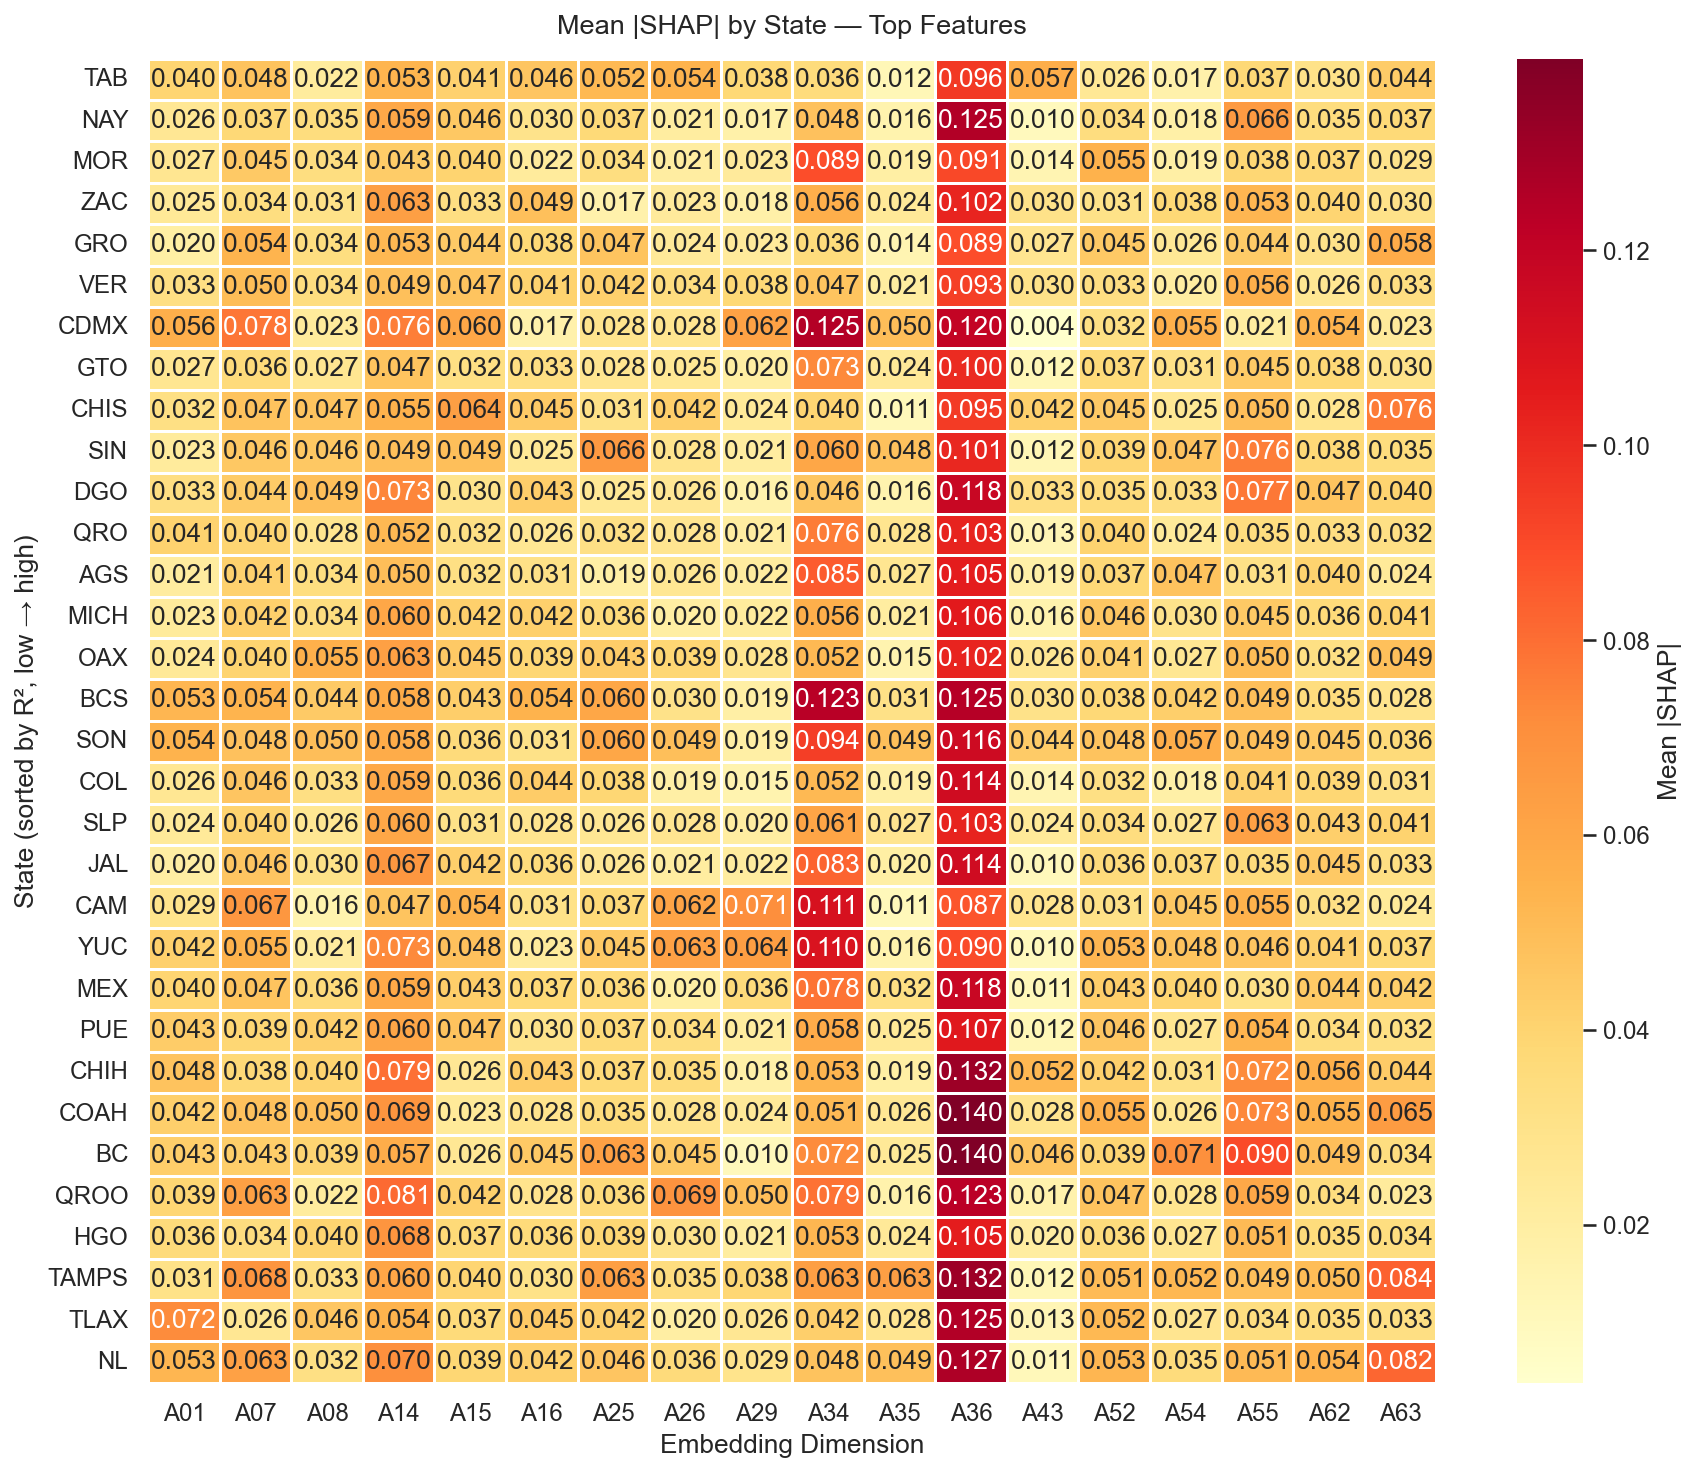

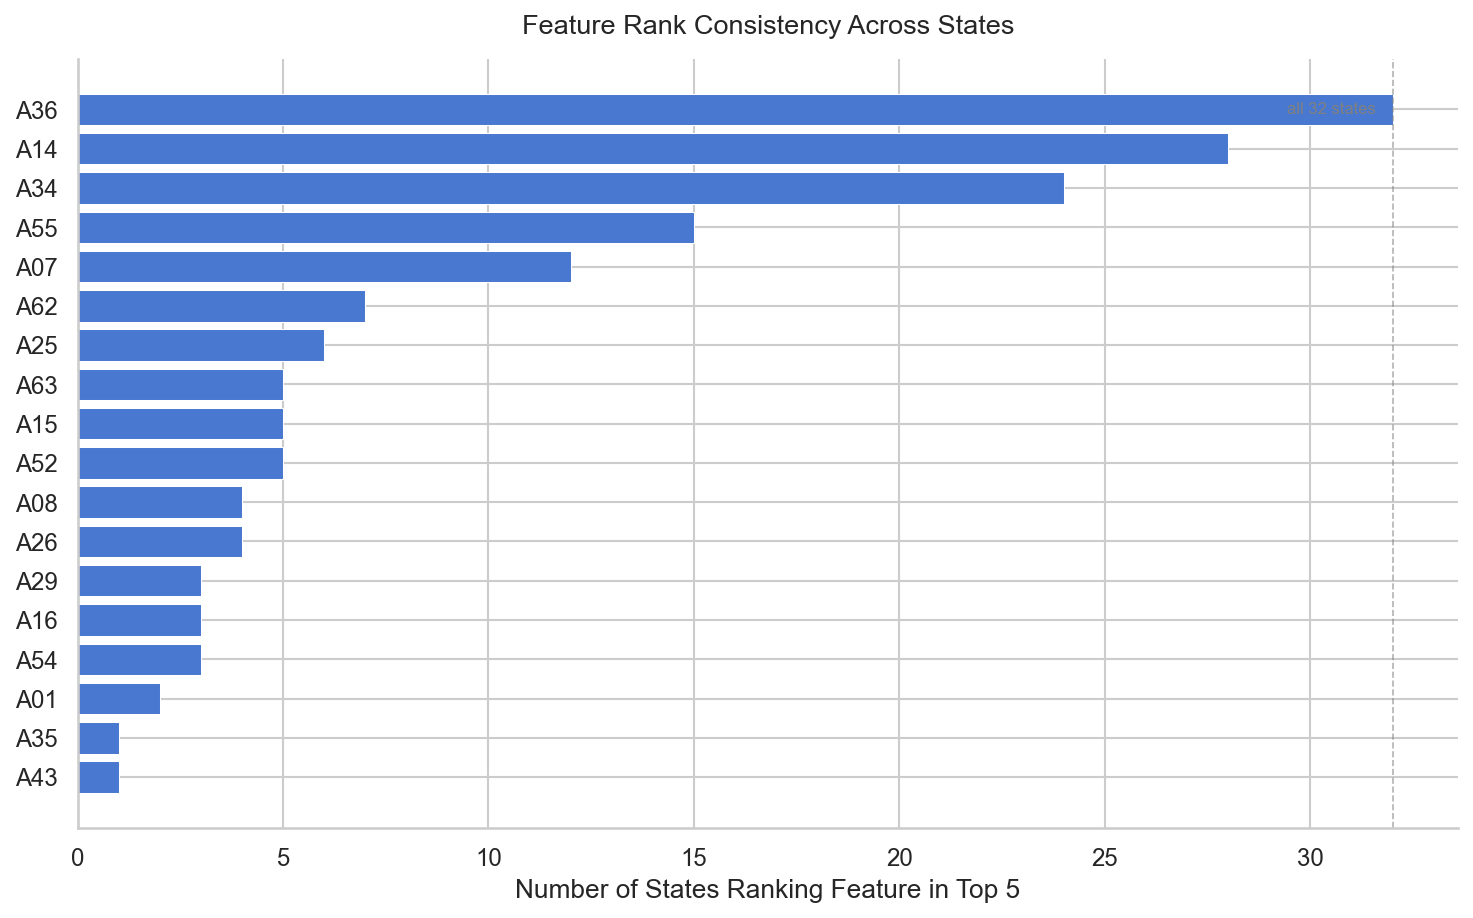

In [33]:
r2_order = state_df.sort_values("R²", ascending=True).index
heatmap_data = state_shap.loc[r2_order, top_feats]

fig, ax = plt.subplots(figsize=(max(12, len(top_feats) * 0.6), 10))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Mean |SHAP|"},
            ax=ax)
ax.set_title("Mean |SHAP| by State — Top Features", fontsize=13, pad=12)
ax.set_ylabel("State (sorted by R², low → high)")
ax.set_xlabel("Embedding Dimension")
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_15a.png")
plt.show()

top5_counts = pd.Series(0, index=model_features)
for state in state_shap.index:
    for feat in state_shap.loc[state].nlargest(5).index:
        top5_counts[feat] += 1
top5_counts = top5_counts[top5_counts > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(top5_counts) * 0.35)))
ax.barh(range(len(top5_counts)), top5_counts.values, color=pal[0],
        edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top5_counts)))
ax.set_yticklabels(top5_counts.index)
ax.set_xlabel("Number of States Ranking Feature in Top 5")
ax.set_title("Feature Rank Consistency Across States", fontsize=13, pad=12)
ax.axvline(x=len(state_shap), color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.annotate(f"all {len(state_shap)} states", xy=(len(state_shap), len(top5_counts) - 1),
            xytext=(-8, 0), textcoords="offset points", fontsize=8,
            color="grey", ha="right", va="center")
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_15b.png")
plt.show()